In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.viz import (
    setup_style, correlation_heatmap, pareto_panel_multi,
    phase_breakdown_stacked, throttling_heatmap,
    hw_distributions_panel, temp_freq_dual,
    cpu_memory_dual_phases,
)
setup_style()

DATA_BASE = Path('../data/TFG-DATA')
EXP_FAN   = DATA_BASE / 'E0-FAN'
EXP_NOFAN = DATA_BASE / 'E0-NOFAN'

_runs_fan_all   = load_collection(EXP_FAN).runs   if EXP_FAN.exists()   else []
_runs_nofan_all = load_collection(EXP_NOFAN).runs if EXP_NOFAN.exists() else []

ENGINE = 'LLAMA'
runs_fan   = [r for r in _runs_fan_all   if r.summary.inference_engine == ENGINE]
runs_nofan = [r for r in _runs_nofan_all if r.summary.inference_engine == ENGINE]

coll = RunCollection(runs_fan + runs_nofan)

summary = coll.summary_df()
hw_df   = coll.hw_metrics_df()
pm_df   = coll.prompt_metrics_df()

print(f'Engine: {ENGINE}')
print(f'Runs loaded: {len(coll.runs)}')
print(f'  · With fan:    {len(runs_fan)}')
print(f'  · Without fan: {len(runs_nofan)}')
print(f'  · Runs in summary:   {len(summary)}')
n_valid = len(pm_df[~pm_df["is_empty_generation"]]) if not pm_df.empty else 0
print(f'  · Valid prompts:   {n_valid}')

# Add config_label = "model\n(FAN/NOFAN)" for charts
if not summary.empty:
    summary["config_label"] = (
        summary["model_label"] + "\n(" +
        summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
    )
    _cl = summary[["run_id", "config_label"]]
    if not hw_df.empty:
        hw_df = hw_df.merge(_cl, on="run_id", how="left")
    if not pm_df.empty:
        pm_df = pm_df.merge(_cl, on="run_id", how="left")

# ── HW aggregates per run (only during active inference: cpu > 10%) ──────────

# 1. Mean CPU frequency during inference
if not hw_df.empty and "freq_mean_ghz" in hw_df.columns:
    freq_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")["freq_mean_ghz"]
        .mean()
        .rename("freq_mean_inference_ghz")
        .reset_index()
    )
    summary = summary.merge(freq_agg, on="run_id", how="left")

# 2. Mean fan speed during inference
FAN_COL = "fan_rpm"   # name in hw_df (mapped from fan_speed_ in _parsers.py)

if not hw_df.empty and FAN_COL in hw_df.columns:
    fan_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")[FAN_COL]
        .mean()
        .rename("fan_speed_mean")
        .reset_index()
    )
    summary = summary.merge(fan_agg, on="run_id", how="left")
    print(f"fan_speed_mean added: {summary['fan_speed_mean'].notna().sum()} runs with data")
else:
    print(f"Fan column not found. Available: "
          f"{[c for c in hw_df.columns if 'fan' in c.lower()]}")

# 3. Actual parameter count (exact integer, not abbreviated)
if "n_params" not in summary.columns:
    run_map_p = {r.run_id: r for r in coll.runs}
    summary["n_params"] = [
        (run_map_p[rid].summary.model_info or {}).get("n_params", float("nan"))
        if rid in run_map_p else float("nan")
        for rid in summary["run_id"]
    ]

# Quick check of the new columns
_check_cols = ["freq_mean_inference_ghz", "fan_speed_mean", "n_params"]
print(summary[[c for c in _check_cols if c in summary.columns]
              + ["model_label", "fan"]].round(4))

# Aliases for consistency with E1-E5 (which use hw_full / pm_full)
hw_full = hw_df
pm_full = pm_df


tokenProb size mismatch in run=1780948937859414717 prompt=7: got 266 tokens, eval_count=-1


Engine: LLAMA
Runs loaded: 12
  · With fan:    6
  · Without fan: 6
  · Runs in summary:   12
  · Valid prompts:   178
fan_speed_mean added: 12 runs with data
    freq_mean_inference_ghz  fan_speed_mean      n_params           model_label    fan
0                    2.4000       7383.4430  3.429006e+09         ministral (L)   True
1                    2.4000       7424.1816  3.212750e+09      Llama-3.2-3B (L)   True
2                    2.4000       7229.8031  1.235814e+09      Llama-3.2-1B (L)   True
3                    2.4000       7182.4896  3.191396e+09           granite (L)   True
4                    2.4000       7267.6001  1.910000e+09             gemma (L)   True
5                    2.4000       7491.2552  1.777088e+09  DeepSeek-R1-1.5B (L)   True
6                    1.0497          0.0000  3.429006e+09         ministral (L)  False
7                    1.0842          0.0000  3.212750e+09      Llama-3.2-3B (L)  False
8                    1.0854          0.0000  1.235814e+09 

1# E0 — Baseline comparison between models

## Research question
Which LLM model offers the best performance/efficiency trade-off on a
Raspberry Pi 5 under standard inference conditions?
How does active cooling (fan) affect sustained performance?

## Hypothesis
- Smaller models (1B) will be faster but with lower quality.
- The fan will reduce thermal throttling and improve sustained throughput.
- Mean power will be similar across models (limited by the SoC),
  but energy per token will vary with each model's speed.

## Experiment configuration
| Parameter       | Fixed value                            |
|-----------------|----------------------------------------|
| batch_size      | 512                                    |
| context_size    | 4096                                   |
| quantization    | Q4_K_M                                 |
| temperature     | 0.0                                    |
| num_prompts     | 15 (IFEval)                            |
| hardware        | Raspberry Pi 5 (BCM2712, 8 GB LPDDR4X) |

| Variable        | Values                                              |
|-----------------|-----------------------------------------------------|
| model           | Ministral-3B, Llama3.2-1B, Llama3.2-3B,           |
|                 | DeepSeek-Qwen-1.5B, Gemma3n-e2b                    |
| cooling         | With fan (FAN) / Without fan (NOFAN)                |


# 📊 Figures and tables for the thesis

Main section of experiment E0. Supplementary material is in the **📎 Appendix** at the end.

| # | Figure/Table |
|---|---|
| 1 | Master characterization table (N params, tok/s, TTFT, J/tok, RAM, MBU_corr, η, FoM, usability) |
| 2 | Pareto frontier: speed vs RAM footprint (bubble size = FoM_full) |
| 3 | FoM_full decomposed by normalized axes |
| 4 | Cooling impact: Δ% throughput FAN vs NOFAN |
| 5 | E0.4 — Temporal breakdown by phase (load / prefill / decode): FAN vs NOFAN compared |
| 6 | E0.5 — Computational work and efficiency by phase (W_CPU, η_CPU): FAN vs NOFAN compared |



## Figure of Merit (FoM_full)

Combines four axes normalized against the reference configuration
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Axis | Normalization | Meaning |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput weighted by size |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Bandwidth utilization (corrected) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Computational efficiency |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J weighted by size |

**FoM_full > 1** → the configuration beats the reference in geometric mean.



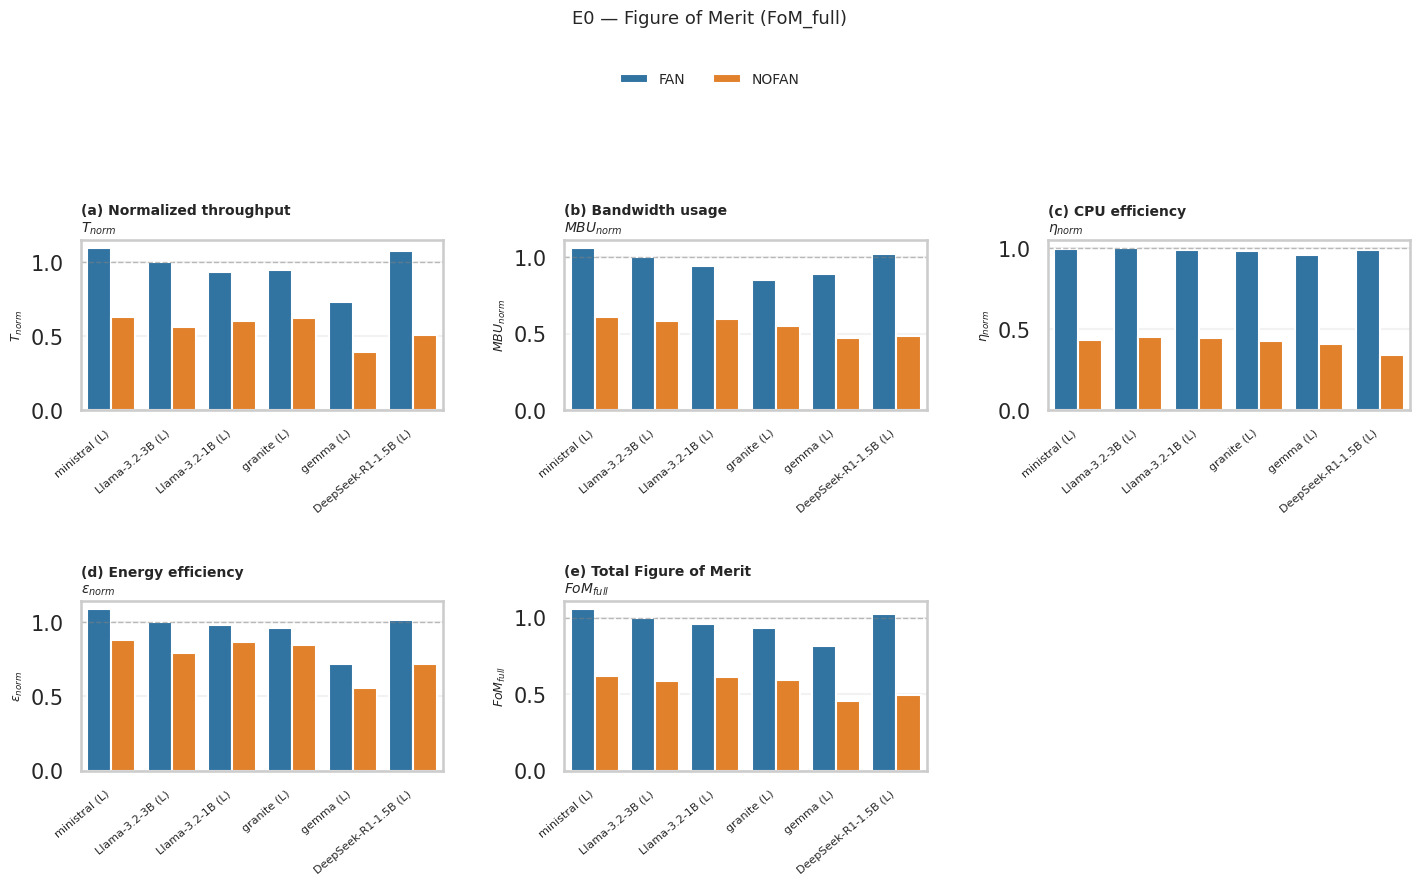

FoM_full by configuration:


,model_label,_fan_label,mbu_corr,tokens_per_s_mean,fom_full
0,ministral (L),FAN,66.133,4.731,1.058
1,Llama-3.2-3B (L),FAN,62.465,4.608,1.000
2,Llama-3.2-1B (L),FAN,58.785,11.229,0.961
3,granite (L),FAN,52.965,4.410,0.934
4,gemma (L),FAN,55.464,5.683,0.818
5,DeepSeek-R1-1.5B (L),FAN,63.653,8.978,1.025
6,ministral (L),NOFAN,37.957,2.714,0.618
7,Llama-3.2-3B (L),NOFAN,36.166,2.602,0.585
8,Llama-3.2-1B (L),NOFAN,37.267,7.236,0.610
9,granite (L),NOFAN,34.299,2.879,0.593



Usability criterion (≥3 words/s): 8/12 usable runs


,model_label,tokens_per_s_mean,T_hum,usable
0,ministral (L),4.731,4.522,True
1,Llama-3.2-3B (L),4.608,4.252,True
2,Llama-3.2-1B (L),11.229,4.416,True
3,granite (L),4.410,3.987,True
4,gemma (L),5.683,4.449,True
5,DeepSeek-R1-1.5B (L),8.978,3.691,True
6,ministral (L),2.714,4.522,False
7,Llama-3.2-3B (L),2.602,4.252,False
8,Llama-3.2-1B (L),7.236,4.416,True
9,granite (L),2.879,3.987,False


In [2]:
# ── FoM_full — Composite Figure of Merit (E0) ─────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_pm = (pm_full if "pm_full" in dir() else
       pm_df   if "pm_df"   in dir() else pd.DataFrame())
_FOM_AXES = {
    "fom_T_norm":   (r"$T_{norm}$",          "Normalized throughput"),
    "fom_MBU_norm": (r"$MBU_{norm}$",         "Bandwidth usage"),
    "fom_eta_norm": (r"$\eta_{norm}$",        "CPU efficiency"),
    "fom_eps_norm": (r"$\varepsilon_{norm}$", "Energy efficiency"),
    "fom_full":     ("$FoM_{full}$",           "Total Figure of Merit"),
}
_PANEL = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
_x_col = "model_label"
_hue   = "fan" if "fan" in summary.columns else None

try:
    fom_df = compute_fom_full(summary)
    if "fan" in fom_df.columns:
        fom_df["_fan_label"] = fom_df["fan"].map({True: "FAN", False: "NOFAN"})
        _hue = "_fan_label"
    avail = [col for col in _FOM_AXES if col in fom_df.columns and fom_df[col].notna().any()]

    if avail:
        _nc = 3
        _nr = (len(avail) + _nc - 1) // _nc
        fig, _axes = plt.subplots(_nr, _nc, figsize=(_nc * 5, _nr * 4.2))
        _axes_flat = _axes.flatten() if _nr > 1 else list(_axes)

        for idx, (ax, col) in enumerate(zip(_axes_flat, avail)):
            d = fom_df.dropna(subset=[col])
            kw = dict(data=d, x=_x_col, y=col, ax=ax)
            if _hue and _hue in d.columns:
                kw["hue"] = _hue
            sns.barplot(**kw)

            math_lbl, desc_lbl = _FOM_AXES[col]
            ax.set_title(f"{_PANEL[idx]} {desc_lbl}\n{math_lbl}",
                         fontsize=10, fontweight="bold", loc="left", pad=6)
            ax.set_xlabel("")
            ax.set_ylabel(math_lbl, fontsize=9)
            plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
            ax.axhline(1.0, ls="--", color="gray", alpha=0.5, lw=1)
            ax.grid(True, axis="y", alpha=0.25)
            if ax.get_legend():
                ax.get_legend().remove()

        for ax in _axes_flat[len(avail):]:
            ax.set_visible(False)

        # Shared legend above
        _all_h, _all_l = [], []
        for _ax in _axes_flat[:len(avail)]:
            h, l = _ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in _all_l:
                    _all_h.append(hh); _all_l.append(ll)
        if _all_h:
            fig.legend(_all_h, _all_l, loc="upper center",
                       bbox_to_anchor=(0.5, 1.03), ncol=len(_all_h), fontsize=10)
        fig.suptitle("E0 — Figure of Merit (FoM_full)", fontsize=13, y=1.09)
        fig.tight_layout(pad=2.0)
        plt.show()

        _disp = [c for c in [_x_col, _hue, "mbu_corr", "tokens_per_s_mean", "fom_full"]
                 if c and c in fom_df.columns]
        print("FoM_full by configuration:")
        display(fom_df[_disp].round(3))

    if not _pm.empty:
        fom_df, _tpw = compute_usability(fom_df, _pm)
        n_usable = int(fom_df["usable"].sum()) if "usable" in fom_df.columns else 0
        print(f"\nUsability criterion (≥3 words/s): {n_usable}/{len(fom_df)} usable runs")
        _uc = [c for c in [_x_col, "tokens_per_s_mean", "T_hum", "usable"] if c in fom_df.columns]
        if _uc:
            display(fom_df[_uc].round(3))
except Exception as e:
    print(f"Error in FoM: {e}")

In [3]:
# ── Table 1 — E0 base characterization (sorted: usable ↑, FoM_full ↓) ─────
try:
    _t = fom_df.copy()

    # RAM at runtime (mean hw_metrics) in metric GB
    _hw_src = hw_df if "hw_df" in vars() else pd.DataFrame()
    if not _hw_src.empty and "mem_used_bytes" in _hw_src.columns and "run_id" in _t.columns:
        _ram_rt = _hw_src.groupby("run_id")["mem_used_bytes"].mean().reset_index()
        _ram_rt["ram_used_gb"] = _ram_rt["mem_used_bytes"] / 1e9
        _t = _t.merge(_ram_rt[["run_id", "ram_used_gb"]], on="run_id", how="left")

    # σ from per-prompt metrics (intra-run variability)
    _pm_src = pm_full if "pm_full" in vars() else (pm_df if "pm_df" in vars() else pd.DataFrame())
    if not _pm_src.empty and "run_id" in _pm_src.columns and "run_id" in _t.columns:
        _valid_pm = (_pm_src[~_pm_src["is_empty_generation"]]
                     if "is_empty_generation" in _pm_src.columns else _pm_src)
        _std_grp = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                    if c in _valid_pm.columns]
        if _std_grp:
            _std_df = (
                _valid_pm.groupby("run_id")[_std_grp].std().reset_index()
                .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                                 "time_to_first_token_ms": "ttft_ms_std",
                                 "perplexity":             "perplexity_std"})
            )
            _t = _t.merge(_std_df, on="run_id", how="left")

    _col_map = [
        ("model_label",          "Model"),
        ("fan",                  "FAN"),
        ("n_params",             "N params"),
        ("ram_used_gb",           "RAM (GBytes)"),
        ("tokens_per_s_mean",    "tok/s"),
        ("tokens_per_s_std",     "σ tok/s"),
        ("ttft_ms_mean",         "TTFT (ms)"),
        ("ttft_ms_std",          "σ TTFT"),
        ("energy_per_token_j",   "J/token"),
        ("mbu_corr",             "MBU_corr (%)"),
        ("cpu_efficiency",       "η_CPU"),
        ("perplexity_geomean",   "PPL"),
        ("perplexity_std",       "σ PPL"),
        ("fom_full",             "FoM_full"),
        ("usable",               "Usable"),
    ]
    _raw = {}
    for src_col, label in _col_map:
        if src_col in _t.columns:
            _raw[label] = _t[src_col].reset_index(drop=True)
    _raw_df = pd.DataFrame(_raw)

    # Sort: usable first, then FoM desc
    _sort_cols, _sort_asc = [], []
    if "Usable" in _raw_df.columns:
        _sort_cols.append("Usable"); _sort_asc.append(False)
    if "FoM_full" in _raw_df.columns:
        _sort_cols.append("FoM_full"); _sort_asc.append(False)
    if _sort_cols:
        _raw_df = _raw_df.sort_values(_sort_cols, ascending=_sort_asc).reset_index(drop=True)

    # Display formatting
    _fmt_rules = {
        "FAN":           lambda x: "✓" if x else "✗",
        "N params":      lambda x: f"{x/1e9:.2f} B" if pd.notna(x) and float(x) > 0 else "—",
        "RAM (GBytes)":  lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "tok/s":         lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "σ tok/s":       lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "TTFT (ms)":     lambda x: f"{x:.0f}"        if pd.notna(x) else "—",
        "σ TTFT":        lambda x: f"{x:.0f}"        if pd.notna(x) else "—",
        "J/token":       lambda x: f"{x:.4f}"        if pd.notna(x) else "—",
        "MBU_corr (%)":  lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "η_CPU":         lambda x: f"{x:.3f}"        if pd.notna(x) else "—",
        "PPL":           lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "σ PPL":         lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "FoM_full":      lambda x: f"{x:.3f}"        if pd.notna(x) else "—",
        "Usable":        lambda x: "✓" if x else "✗",
    }
    _disp = _raw_df.copy()
    for col, fn in _fmt_rules.items():
        if col in _disp.columns:
            _disp[col] = _disp[col].apply(fn)

    _disp.index = range(1, len(_disp) + 1)
    print("Table 1 — E0 base characterization (usable ↑ first, then FoM_full ↓)")
    display(_disp)

except NameError:
    print("fom_df not defined — run the FoM_full cell first.")
except Exception as e:
    import traceback; traceback.print_exc()


Table 1 — E0 base characterization (usable ↑ first, then FoM_full ↓)


,Model,FAN,N params,RAM (GBytes),tok/s,σ tok/s,TTFT (ms),σ TTFT,J/token,MBU_corr (%),η_CPU,PPL,σ PPL,FoM_full,Usable
1,ministral (L),✓,3.43 B,3.01,4.7,0.7,1929,1310,1.4400,66.1,0.980,2.81,0.59,1.058,✓
2,DeepSeek-R1-1.5B (L),✓,1.78 B,1.51,9.0,1.3,951,554,0.7992,63.7,0.975,2.75,0.93,1.025,✓
3,Llama-3.2-3B (L),✓,3.21 B,2.91,4.6,1.1,1941,1202,1.4689,62.5,0.987,2.29,1.10,1.000,✓
4,Llama-3.2-1B (L),✓,1.24 B,1.36,11.2,2.5,673,363,0.5770,58.8,0.975,2.36,1.26,0.961,✓
5,granite (L),✓,3.19 B,2.46,4.4,0.1,2348,1611,1.5188,53.0,0.968,2.85,0.90,0.934,✓
6,gemma (L),✓,1.91 B,2.16,5.7,0.1,2613,1885,1.2141,55.5,0.946,2.42,0.72,0.818,✓
7,Llama-3.2-1B (L),✗,1.24 B,1.36,7.2,2.1,1214,440,0.6541,37.3,0.440,2.36,1.26,0.610,✓
8,DeepSeek-R1-1.5B (L),✗,1.78 B,1.51,4.2,0.4,2391,924,1.1290,30.4,0.337,2.75,0.93,0.497,✓
9,ministral (L),✗,3.43 B,3.01,2.7,0.5,3703,1476,1.7842,38.0,0.429,2.81,0.59,0.618,✗
10,granite (L),✗,3.19 B,2.46,2.9,0.3,4227,1893,1.7218,34.3,0.422,2.85,0.90,0.593,✗


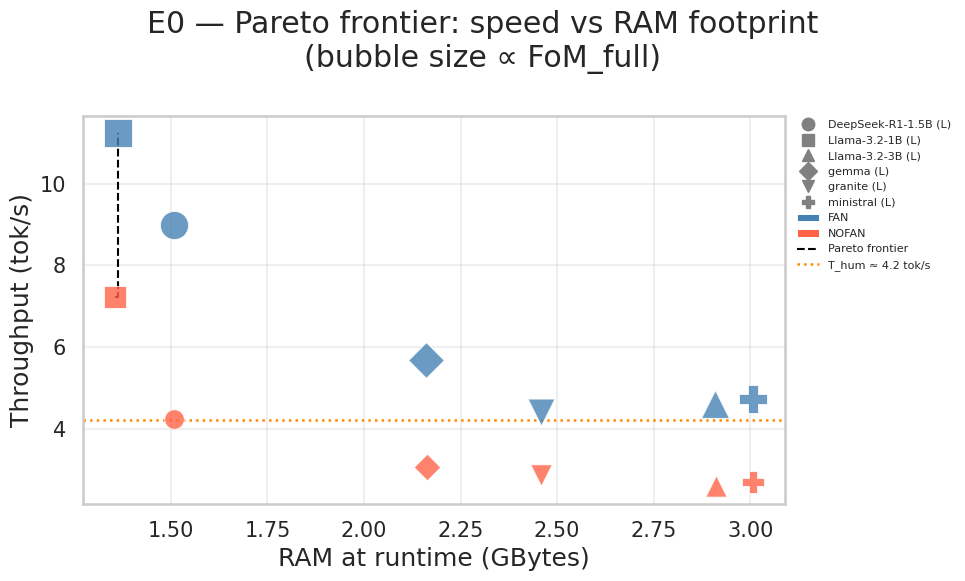

In [4]:
# ── Figure 2 — Pareto frontier: tok/s vs RAM footprint ──────────────────────
# x=RAM at runtime (GBytes), y=tok/s, bubble∝FoM_full, shape=model, color=FAN/NOFAN
try:
    def _pf(df, x_col, y_col, x_lower=True, y_lower=False):
        pts = df[[x_col, y_col]].to_numpy()
        n = len(pts)
        dom = [False] * n
        for i in range(n):
            for j in range(n):
                if i == j: continue
                xok = (pts[j,0] <= pts[i,0]) if x_lower else (pts[j,0] >= pts[i,0])
                yok = (pts[j,1] <= pts[i,1]) if y_lower else (pts[j,1] >= pts[i,1])
                if xok and yok and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                    dom[i] = True; break
        return df.iloc[[not d for d in dom]].sort_values(x_col)

    # Runtime RAM from hw_df
    _fom_pareto = fom_df.copy()
    _hw_p = hw_df if "hw_df" in vars() else pd.DataFrame()
    if not _hw_p.empty and "mem_used_bytes" in _hw_p.columns and "run_id" in _fom_pareto.columns:
        _rp = _hw_p.groupby("run_id")["mem_used_bytes"].mean().reset_index()
        _rp["ram_used_gb"] = _rp["mem_used_bytes"] / 1e9
        _fom_pareto = _fom_pareto.merge(_rp[["run_id","ram_used_gb"]], on="run_id", how="left")

    _need = ["ram_used_gb", "tokens_per_s_mean"]
    _pd = _fom_pareto.dropna(subset=_need).copy()

    if _pd.empty:
        print("Not enough data for Pareto.")
    else:
        _has_fom = "fom_full" in _pd.columns and _pd["fom_full"].notna().any()
        _has_fan = "fan" in _pd.columns and _pd["fan"].nunique() > 1
        _fan_colors = {True: "steelblue", False: "tomato"}
        _fan_labels = {True: "FAN", False: "NOFAN"}

        # Markers per model
        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]
        _models_sorted = sorted(_pd["model_label"].unique())
        _mk_map = {m: _MARKER_POOL[i % len(_MARKER_POOL)]
                   for i, m in enumerate(_models_sorted)}

        fig, ax = plt.subplots(figsize=(10, 6))

        for _fan_val in ([True, False] if _has_fan else [None]):
            _sub = _pd[_pd["fan"] == _fan_val] if _fan_val is not None else _pd
            if _sub.empty: continue
            _color = _fan_colors.get(_fan_val, "steelblue")
            for _, row in _sub.iterrows():
                _sz = float(row["fom_full"]) * 400 if _has_fom and pd.notna(row.get("fom_full")) else 150
                ax.scatter(row["ram_used_gb"], row["tokens_per_s_mean"],
                           s=max(_sz, 30), c=_color, marker=_mk_map[row["model_label"]],
                           alpha=0.80, zorder=3, edgecolors="white", linewidths=0.7)

        # Pareto frontier
        _front = _pf(_pd, "ram_used_gb", "tokens_per_s_mean")
        if len(_front) > 1:
            ax.step(_front["ram_used_gb"], _front["tokens_per_s_mean"],
                    where="post", color="black", lw=1.5, ls="--", zorder=2)

        # T_hum line
        if "T_hum" in _pd.columns and _pd["T_hum"].notna().any():
            _t_hum = _pd["T_hum"].mean()
            ax.axhline(_t_hum, color="darkorange", ls=":", lw=1.8)

        ax.set_xlabel("RAM at runtime (GBytes)")
        ax.set_ylabel("Throughput (tok/s)")
        fig.suptitle("E0 — Pareto frontier: speed vs RAM footprint\n"
                     "(bubble size ∝ FoM_full)")
        ax.grid(True, alpha=0.3)

        # Outer legend: models (shape) + fan (color) + references
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        _legend_h = (
            [Line2D([0],[0], marker=_mk_map[m], color="gray", markerfacecolor="gray",
                     ms=9, label=m, ls="None") for m in _models_sorted]
            + [Patch(facecolor=c, edgecolor="white", linewidth=0.7, label=lbl)
               for c, lbl in [("steelblue","FAN"), ("tomato","NOFAN")]]
            + [Line2D([0],[0], color="black", lw=1.5, ls="--", label="Pareto frontier")]
        )
        if "T_hum" in _pd.columns and _pd["T_hum"].notna().any():
            _legend_h.append(
                Line2D([0],[0], color="darkorange", lw=1.8, ls=":",
                        label=f"T_hum ≈ {_pd['T_hum'].mean():.1f} tok/s")
            )
        ax.legend(handles=_legend_h, fontsize=8,
                  bbox_to_anchor=(1.01, 1), loc="upper left",
                  borderaxespad=0, framealpha=0.9)
        fig.tight_layout()
        plt.show()

except NameError:
    print("fom_df not defined — run the FoM_full cell first.")
except Exception as e:
    import traceback; traceback.print_exc()


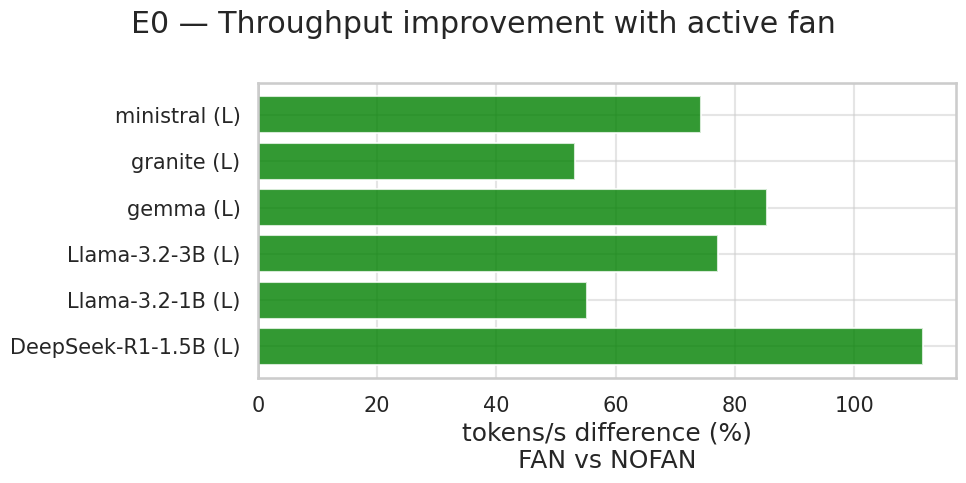


Absolute and percentage difference (FAN vs NOFAN):


,diff_tok_s,diff_pct
model_label,,
DeepSeek-R1-1.5B (L),4.733,111.5
Llama-3.2-1B (L),3.993,55.2
Llama-3.2-3B (L),2.006,77.1
gemma (L),2.616,85.3
granite (L),1.531,53.2
ministral (L),2.017,74.3


In [5]:
if (not summary.empty and 'fan' in summary.columns
        and 'tokens_per_s_mean' in summary.columns):
    fan_mean   = summary[summary['fan'] == True].groupby('model_label')['tokens_per_s_mean'].mean()
    nofan_mean = summary[summary['fan'] == False].groupby('model_label')['tokens_per_s_mean'].mean()
    common = fan_mean.index.intersection(nofan_mean.index)
    if len(common) > 0:
        diff     = fan_mean.loc[common] - nofan_mean.loc[common]
        diff_pct = diff / nofan_mean.loc[common] * 100
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['green' if v > 0 else 'red' for v in diff_pct]
        ax.barh(common.tolist(), diff_pct.values, color=colors, alpha=0.8)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('tokens/s difference (%)\nFAN vs NOFAN')
        fig.suptitle('E0 — Throughput improvement with active fan')
        ax.tick_params(axis='y', rotation=0)
        plt.tight_layout()
        plt.show()

        print('\nAbsolute and percentage difference (FAN vs NOFAN):')
        display(pd.DataFrame({'diff_tok_s': diff.round(3), 'diff_pct': diff_pct.round(1)}))
    else:
        print('No common models between FAN and NOFAN.')
else:
    print('No data for fan/nofan comparison.')

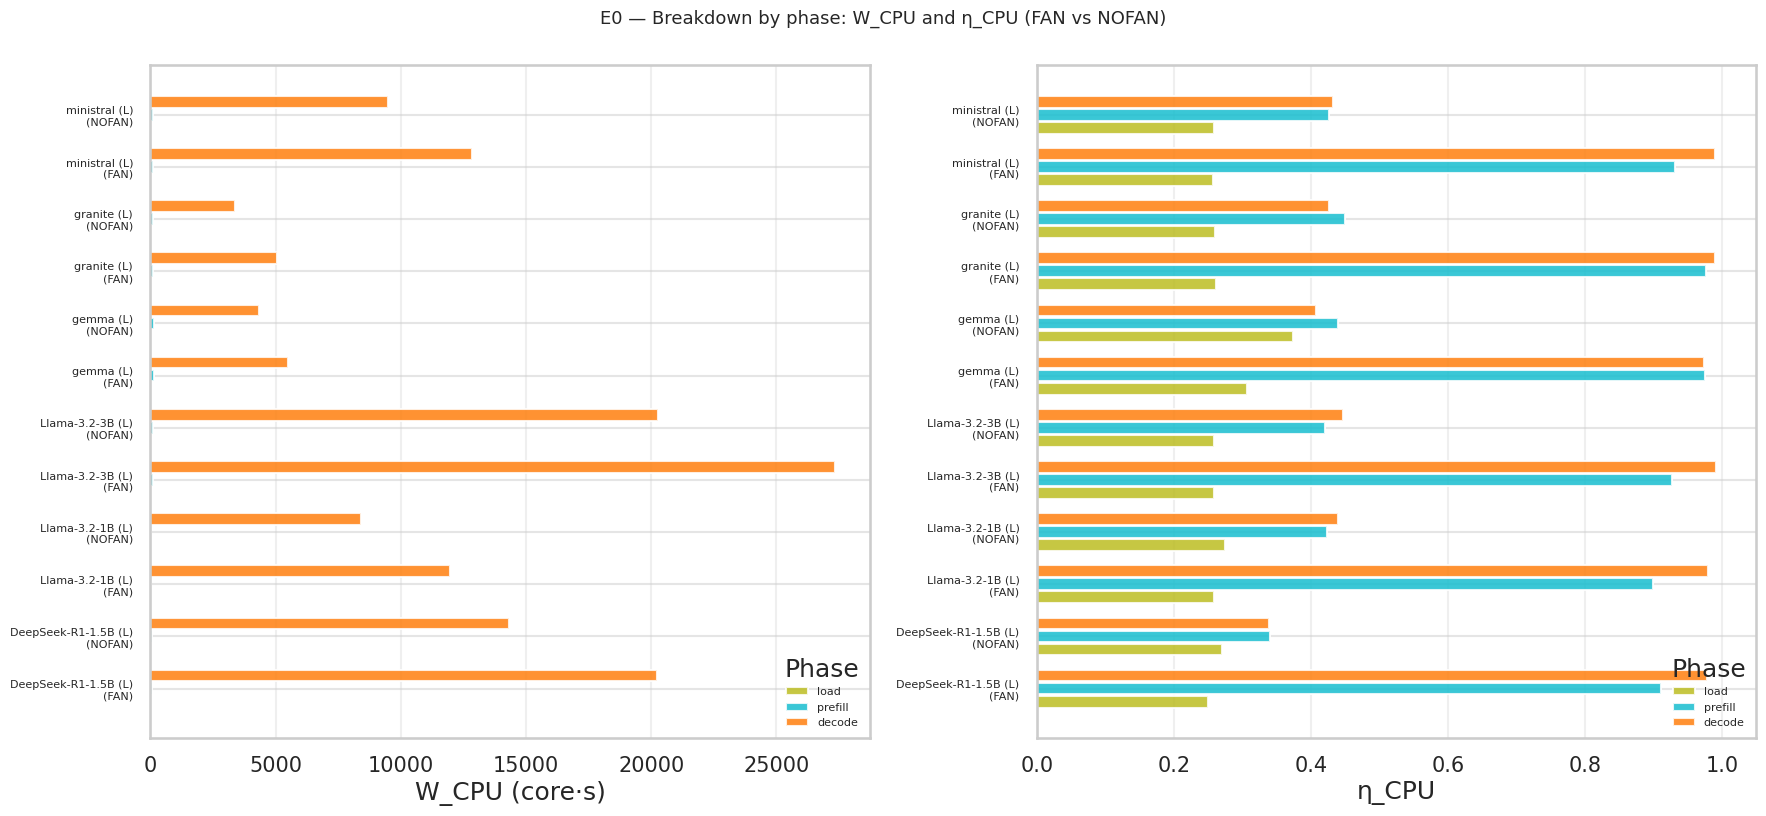

In [6]:
phase_df = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not phase_df.empty:
    if "run_id" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["run_id","config_label","fan"]].drop_duplicates(),
            on="run_id", how="left"
        )
    elif "model_label" in phase_df.columns and "fan" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["model_label","fan","config_label"]].drop_duplicates(),
            on=["model_label","fan"], how="left"
        )
    if "config_label" not in phase_df.columns:
        phase_df["config_label"] = phase_df.get("model_label", "?")

    PHASE_ORDER  = ["load","prefill","decode"]
    PHASE_COLORS = {"load":"#bcbd22","prefill":"#17becf","decode":"#ff7f0e"}
    configs = sorted(phase_df["config_label"].unique())
    y = np.arange(len(configs))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(configs) * 0.7)))
    for ax, (metric, xlabel, xlim) in zip(axes, [
        ("cpu_work_core_s", "W_CPU (core\u00b7s)", None),
        ("cpu_efficiency",  "\u03b7_CPU",           (0, 1.05)),
    ]):
        for i, phase in enumerate(PHASE_ORDER):
            sub  = phase_df[phase_df["phase"] == phase]
            vals = [sub[sub["config_label"] == c][metric].mean()
                    if c in sub["config_label"].values else float('nan')
                    for c in configs]
            ax.barh(y + (i - 1) * width, vals, width * 0.9,
                    label=phase, color=PHASE_COLORS[phase], alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(configs, fontsize=8)
        ax.set_xlabel(xlabel)
        if xlim: ax.set_xlim(*xlim)
        ax.legend(title="Phase", loc="lower right", fontsize=8)
        ax.grid(True, axis='x', alpha=0.3)
    fig.suptitle("E0 \u2014 Breakdown by phase: W_CPU and \u03b7_CPU (FAN vs NOFAN)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('No CPU-work phase data (requires hw data with annotated phases).')


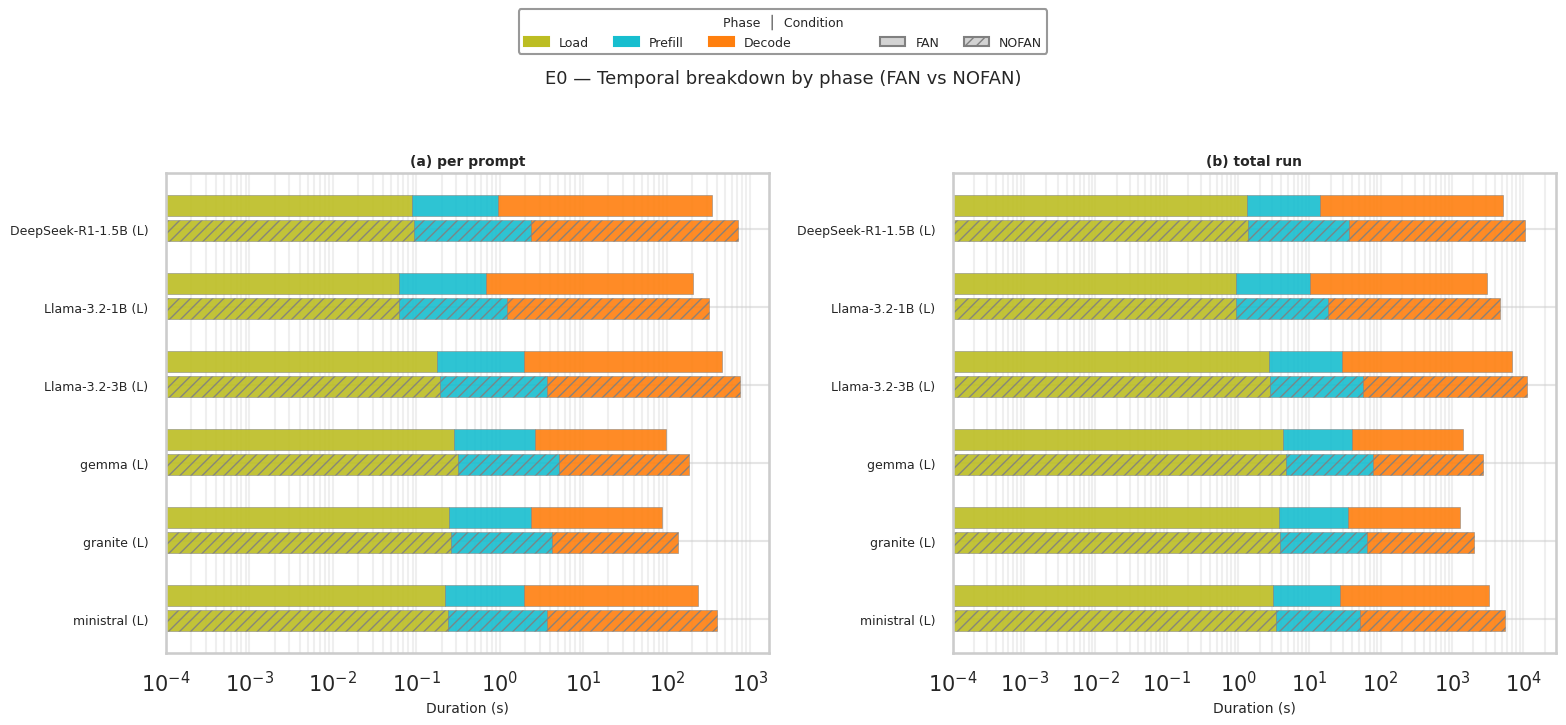

Exported: figures/05_Resultados/E0/e0_desglose_fases.png


In [7]:
# ── E0.4 — Temporal breakdown by phase (FAN vs NOFAN) ─────────────────────────
import os
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

_export_e04 = "figures/05_Resultados/E0/e0_desglose_fases.png"

# Build a dataframe of phase durations directly from the runs
_phase_rows = []
for _run in coll.runs:
    _rid   = _run.run_id
    _label = summary.loc[summary["run_id"] == _rid, "model_label"].values
    _fan   = summary.loc[summary["run_id"] == _rid, "fan"].values
    if len(_label) == 0:
        continue
    _non_empty = [p for p in _run.prompts if not p.is_empty_generation]
    if not _non_empty:
        continue
    _phase_rows.append({
        "model_label":     _label[0],
        "fan":             bool(_fan[0]),
        "load_s":          np.mean([p.load_duration_ns / 1e9 for p in _non_empty]),
        "prefill_s":       np.mean([p.prompt_eval_duration_ns / 1e9 for p in _non_empty]),
        "decode_s":        np.mean([p.eval_duration_ns / 1e9 for p in _non_empty]),
        "load_total_s":    np.sum([p.load_duration_ns / 1e9 for p in _non_empty]),
        "prefill_total_s": np.sum([p.prompt_eval_duration_ns / 1e9 for p in _non_empty]),
        "decode_total_s":  np.sum([p.eval_duration_ns / 1e9 for p in _non_empty]),
    })
_pf2 = pd.DataFrame(_phase_rows)

if not _pf2.empty:
    _PHASES_A = [("load_s",          "Load",    "#bcbd22"),
                 ("prefill_s",       "Prefill", "#17becf"),
                 ("decode_s",        "Decode",  "#ff7f0e")]
    _PHASES_B = [("load_total_s",    "Load",    "#bcbd22"),
                 ("prefill_total_s", "Prefill", "#17becf"),
                 ("decode_total_s",  "Decode",  "#ff7f0e")]

    _models = sorted(_pf2["model_label"].unique())
    _n   = len(_models)
    _bh  = 0.30        # bar height
    _gap = 0.05        # FAN/NOFAN separation within the same model
    _sep = 0.45        # separation between model groups
    _step = 2 * _bh + _gap + _sep

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, _n * 1.1)))
    fig.suptitle("E0 — Temporal breakdown by phase (FAN vs NOFAN)", fontsize=13, y=1.02)

    for ax, phases, subtitle in [
        (axes[0], _PHASES_A, "(a) per prompt"),
        (axes[1], _PHASES_B, "(b) total run"),
    ]:
        ax.set_xscale("log")
        _yticks, _ytlabels = [], []

        for mi, model in enumerate(_models):
            _y_group = mi * _step
            _yticks.append(_y_group + _bh + _gap / 2)
            _ytlabels.append(model)

            for fi, (fan_val, hatch) in enumerate([(True, ""), (False, "///")]):
                sub = _pf2[(_pf2["model_label"] == model) & (_pf2["fan"] == fan_val)]
                if sub.empty:
                    continue
                y_pos = _y_group + fi * (_bh + _gap)
                left = 1e-4  # positive start for log scale
                for col, lbl, color in phases:
                    val = max(float(sub[col].values[0]), 1e-4)
                    ax.barh(y_pos, val, height=_bh, left=left,
                            color=color, hatch=hatch,
                            edgecolor="grey", linewidth=0.4, alpha=0.9)
                    left += val

        ax.set_yticks(_yticks)
        ax.set_yticklabels(_ytlabels, fontsize=9)
        ax.set_xlabel("Duration (s)", fontsize=10)
        ax.set_title(subtitle, fontsize=10)
        ax.grid(True, axis="x", alpha=0.3, which="both")
        ax.invert_yaxis()

    # Dual legend: colors = Phase, fill = Condition
    _ph_handles = [mpatches.Patch(color=c, label=l) for _, l, c in _PHASES_A]
    _cd_handles = [
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="FAN"),
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", label="NOFAN"),
    ]
    _sep_h = Line2D([0], [0], color="none", label=" ")
    fig.legend(handles=_ph_handles + [_sep_h] + _cd_handles,
               loc="upper center", bbox_to_anchor=(0.5, 1.12),
               ncol=len(_ph_handles) + 1 + len(_cd_handles),
               fontsize=9, title="Phase  │  Condition", title_fontsize=9,
               frameon=True, edgecolor="grey")

    plt.tight_layout()
    os.makedirs(os.path.dirname(_export_e04), exist_ok=True)
    fig.savefig(_export_e04, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exported: {_export_e04}")
else:
    print("No temporal phase data.")


In [8]:
# ── E0.4 (table) — Temporal breakdown by phase (FAN vs NOFAN) ─────────────────
# Tabular version of figure e0_desglose_fases.png

# Rebuild _pf2 if the figure cell hasn't been run
if "_pf2" not in vars() or _pf2.empty:
    _rows_t = []
    for _run in coll.runs:
        _rid   = _run.run_id
        _label = summary.loc[summary["run_id"] == _rid, "model_label"].values
        _fan   = summary.loc[summary["run_id"] == _rid, "fan"].values
        if len(_label) == 0:
            continue
        _ne = [p for p in _run.prompts if not p.is_empty_generation]
        if not _ne:
            continue
        _rows_t.append({
            "model_label":     _label[0],
            "fan":             bool(_fan[0]),
            "load_s":          np.mean([p.load_duration_ns        / 1e9 for p in _ne]),
            "prefill_s":       np.mean([p.prompt_eval_duration_ns / 1e9 for p in _ne]),
            "decode_s":        np.mean([p.eval_duration_ns        / 1e9 for p in _ne]),
            "load_total_s":    np.sum([p.load_duration_ns         / 1e9 for p in _ne]),
            "prefill_total_s": np.sum([p.prompt_eval_duration_ns  / 1e9 for p in _ne]),
            "decode_total_s":  np.sum([p.eval_duration_ns         / 1e9 for p in _ne]),
        })
    _pf2 = pd.DataFrame(_rows_t)

if _pf2.empty:
    print("No temporal phase data.")
else:
    _tb = _pf2.copy()
    _tb["total_s"]       = _tb[["load_s", "prefill_s", "decode_s"]].sum(axis=1)
    _tb["total_total_s"] = _tb[["load_total_s", "prefill_total_s", "decode_total_s"]].sum(axis=1)
    for _ph in ["load", "prefill", "decode"]:
        _tb[f"pct_{_ph}"] = 100 * _tb[f"{_ph}_s"] / _tb["total_s"].replace(0, np.nan)
    _tb["cond"] = _tb["fan"].map({True: "FAN", False: "NOFAN"})

    # ── Table A — absolute values and percentage split ─────────────────────
    _colsA = [
        ("model_label",   "Model"),
        ("cond",          "Cond."),
        ("load_s",        "Load (s)"),
        ("prefill_s",     "Prefill (s)"),
        ("decode_s",      "Decode (s)"),
        ("total_s",       "Total (s)"),
        ("pct_load",      "% Load"),
        ("pct_prefill",   "% Prefill"),
        ("pct_decode",    "% Decode"),
        ("load_total_s",  "Load run (s)"),
        ("prefill_total_s", "Prefill run (s)"),
        ("decode_total_s",  "Decode run (s)"),
        ("total_total_s",   "Total run (s)"),
    ]
    _A = pd.DataFrame({lbl: _tb[c] for c, lbl in _colsA if c in _tb.columns})
    _A = _A.sort_values(["Model", "Cond."], ascending=[True, True]).reset_index(drop=True)

    _fmtA = {
        "Load (s)":        lambda x: f"{x:.3f}",
        "Prefill (s)":     lambda x: f"{x:.3f}",
        "Decode (s)":      lambda x: f"{x:.2f}",
        "Total (s)":       lambda x: f"{x:.2f}",
        "% Load":          lambda x: f"{x:.1f}",
        "% Prefill":       lambda x: f"{x:.1f}",
        "% Decode":        lambda x: f"{x:.1f}",
        "Load run (s)":    lambda x: f"{x:.2f}",
        "Prefill run (s)": lambda x: f"{x:.2f}",
        "Decode run (s)":  lambda x: f"{x:.1f}",
        "Total run (s)":   lambda x: f"{x:.1f}",
    }
    _dispA = _A.copy()
    for _c, _fn in _fmtA.items():
        if _c in _dispA.columns:
            _dispA[_c] = _dispA[_c].apply(lambda v: _fn(v) if pd.notna(v) else "—")
    _dispA.index = range(1, len(_dispA) + 1)

    print("Table E0.4a — Temporal breakdown by phase (mean per prompt and total run)")
    display(_dispA)

    # ── Table B — fan impact: Δ% by phase (FAN vs NOFAN) ─────────
    _piv = _tb.pivot_table(index="model_label", columns="fan",
                           values=["load_s", "prefill_s", "decode_s", "total_s"])
    _rowsB = []
    for _m in _piv.index:
        _r = {"Model": _m}
        _ok = True
        for _c, _lbl in [("load_s", "Load"), ("prefill_s", "Prefill"),
                         ("decode_s", "Decode"), ("total_s", "Total")]:
            try:
                _f, _nf = _piv.loc[_m, (_c, True)], _piv.loc[_m, (_c, False)]
            except KeyError:
                _ok = False
                break
            _r[f"Δ% {_lbl}"] = (100 * (_f - _nf) / _nf) if pd.notna(_nf) and _nf > 0 else np.nan
        if _ok:
            _rowsB.append(_r)
    _B = pd.DataFrame(_rowsB)

    if _B.empty:
        print("\nNo common FAN/NOFAN pairs for the Δ%.")
    else:
        _dispB = _B.copy()
        for _c in _dispB.columns:
            if _c != "Model":
                _dispB[_c] = _dispB[_c].apply(lambda v: f"{v:+.1f}" if pd.notna(v) else "—")
        _dispB.index = range(1, len(_dispB) + 1)
        print("\nTable E0.4b — Fan impact by phase: Δ% = (FAN − NOFAN)/NOFAN · 100")
        print("(negative = FAN faster)")
        display(_dispB)


Table E0.4a — Temporal breakdown by phase (mean per prompt and total run)


,Model,Cond.,Load (s),Prefill (s),Decode (s),Total (s),% Load,% Prefill,% Decode,Load run (s),Prefill run (s),Decode run (s),Total run (s)
1,DeepSeek-R1-1.5B (L),FAN,0.088,0.863,344.84,345.79,0.0,0.2,99.7,1.32,12.95,5172.6,5186.9
2,DeepSeek-R1-1.5B (L),NOFAN,0.093,2.298,707.24,709.63,0.0,0.3,99.7,1.39,34.47,10608.5,10644.4
3,Llama-3.2-1B (L),FAN,0.061,0.611,203.49,204.16,0.0,0.3,99.7,0.92,9.17,3052.3,3062.4
4,Llama-3.2-1B (L),NOFAN,0.062,1.152,318.51,319.73,0.0,0.4,99.6,0.93,17.28,4777.7,4795.9
5,Llama-3.2-3B (L),FAN,0.179,1.762,459.79,461.73,0.0,0.4,99.6,2.68,26.43,6896.8,6925.9
6,Llama-3.2-3B (L),NOFAN,0.190,3.528,756.07,759.79,0.0,0.5,99.5,2.84,52.92,11341.1,11396.9
7,gemma (L),FAN,0.286,2.327,94.05,96.66,0.3,2.4,97.3,4.28,34.91,1410.8,1450.0
8,gemma (L),NOFAN,0.314,4.851,176.90,182.07,0.2,2.7,97.2,4.71,72.76,2653.5,2731.0
9,granite (L),FAN,0.246,2.102,85.17,87.52,0.3,2.4,97.3,3.70,31.53,1277.6,1312.8
10,granite (L),NOFAN,0.262,3.965,132.34,136.57,0.2,2.9,96.9,3.93,59.47,1985.1,2048.5



Table E0.4b — Fan impact by phase: Δ% = (FAN − NOFAN)/NOFAN · 100
(negative = FAN faster)


,Model,Δ% Load,Δ% Prefill,Δ% Decode,Δ% Total
1,DeepSeek-R1-1.5B (L),-5.3,-62.4,-51.2,-51.3
2,Llama-3.2-1B (L),-1.0,-47.0,-36.1,-36.1
3,Llama-3.2-3B (L),-5.7,-50.0,-39.2,-39.2
4,gemma (L),-9.1,-52.0,-46.8,-46.9
5,granite (L),-6.0,-47.0,-35.6,-35.9
6,ministral (L),-8.9,-50.6,-41.1,-41.1


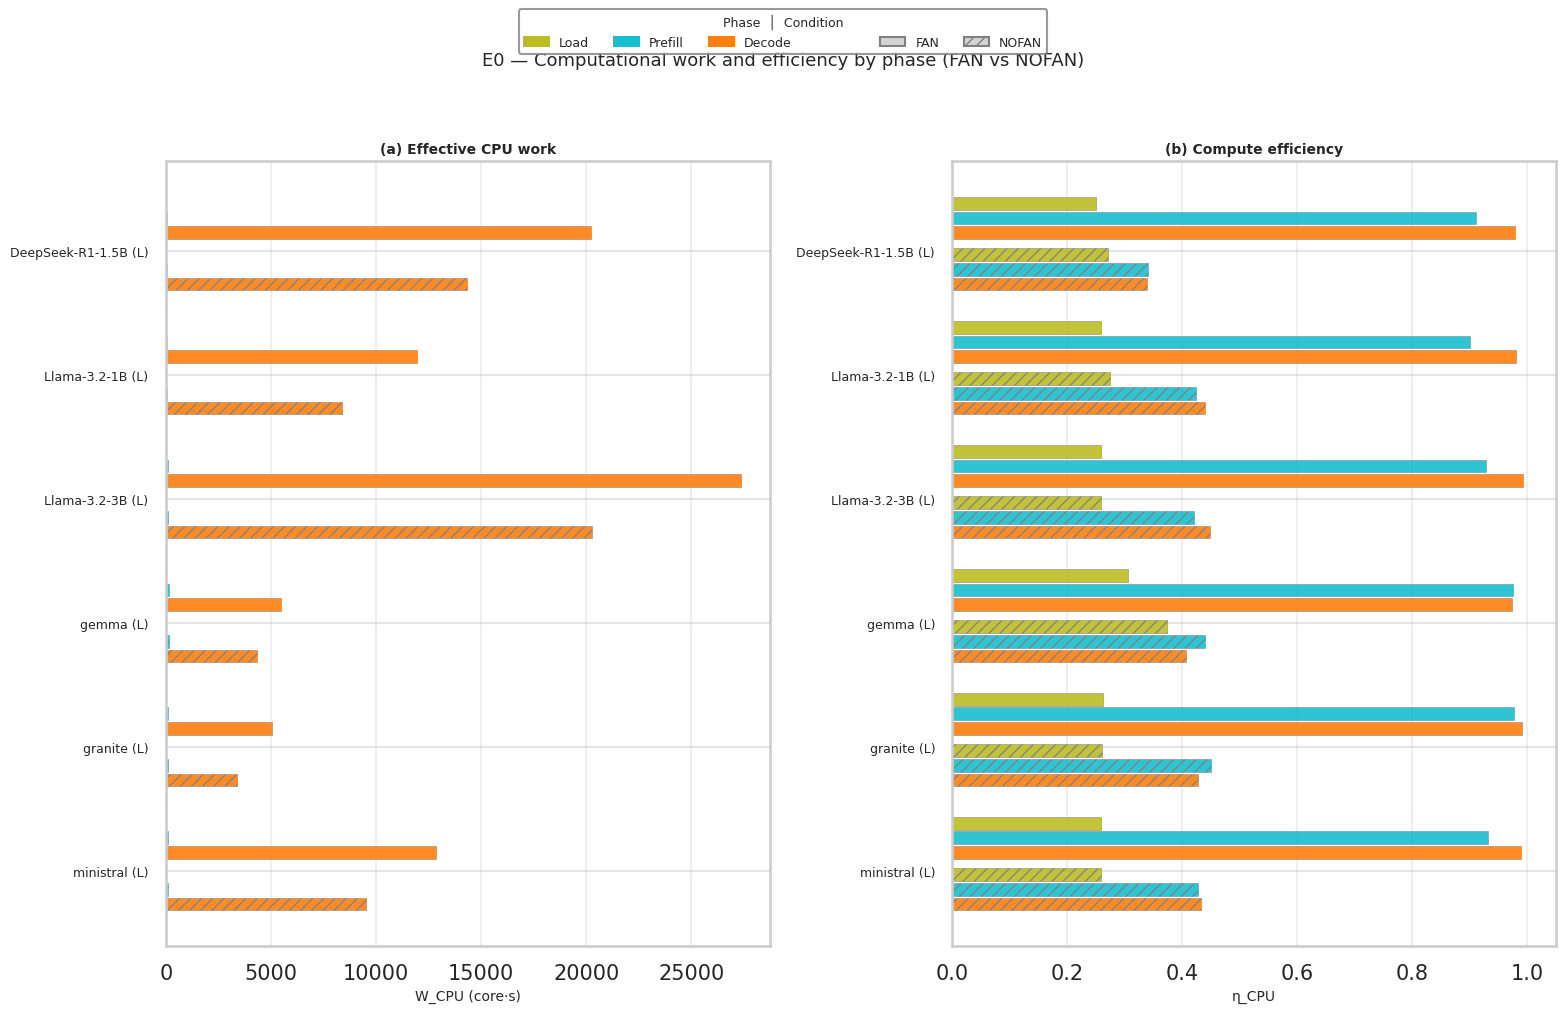

Exported: figures/05_Resultados/E0/e0_trabajo_fases.png


In [9]:
# ── E0.5 — Computational work and efficiency by phase (FAN vs NOFAN) ─────────
import os
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

_export_e05 = "figures/05_Resultados/E0/e0_trabajo_fases.png"

# Get a clean phase_df directly from the collection (includes fan from the start)
_pf_cpu = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not _pf_cpu.empty and "fan" in _pf_cpu.columns:
    _PHASE_C = [("load",    "Load",    "#bcbd22"),
                ("prefill", "Prefill", "#17becf"),
                ("decode",  "Decode",  "#ff7f0e")]

    _models = sorted(_pf_cpu["model_label"].unique())
    _n   = len(_models)
    _bh  = 0.20        # sub-bar height per phase
    _ph_gap  = 0.03    # separation between phases within the same group
    _cond_gap = 0.12   # separation between the FAN and NOFAN groups
    _sep = 0.45        # separation between models
    _group_h = 3 * (_bh + _ph_gap)  # height of the 3-phase block for one condition
    _step = 2 * _group_h + _cond_gap + _sep

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, _n * 1.6)))
    fig.suptitle("E0 — Computational work and efficiency by phase (FAN vs NOFAN)",
                 fontsize=13, y=1.02)

    for ax, metric, xlabel, xlim, subtitle in [
        (axes[0], "cpu_work_core_s", "W_CPU (core·s)", None,       "(a) Effective CPU work"),
        (axes[1], "cpu_efficiency",  "η_CPU",           (0, 1.05), "(b) Compute efficiency"),
    ]:
        _yticks, _ytlabels = [], []

        for mi, model in enumerate(_models):
            _y_model = mi * _step
            _yticks.append(_y_model + _group_h + _cond_gap / 2)
            _ytlabels.append(model)

            for fi, (fan_val, hatch) in enumerate([(True, ""), (False, "///")]):
                y_base = _y_model + fi * (_group_h + _cond_gap)
                for pi, (ph, ph_lbl, color) in enumerate(_PHASE_C):
                    sub = _pf_cpu[
                        (_pf_cpu["model_label"] == model) &
                        (_pf_cpu["fan"] == fan_val) &
                        (_pf_cpu["phase"] == ph)
                    ]
                    if sub.empty:
                        continue
                    val = float(sub[metric].mean())
                    if not np.isfinite(val):
                        continue
                    y_pos = y_base + pi * (_bh + _ph_gap)
                    ax.barh(y_pos, val, height=_bh,
                            color=color, hatch=hatch,
                            edgecolor="grey", linewidth=0.4, alpha=0.9)

        ax.set_yticks(_yticks)
        ax.set_yticklabels(_ytlabels, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(subtitle, fontsize=10)
        if xlim:
            ax.set_xlim(*xlim)
        ax.grid(True, axis="x", alpha=0.3)
        ax.invert_yaxis()

    _ph_handles = [mpatches.Patch(color=c, label=l) for _, l, c in _PHASE_C]
    _cd_handles = [
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="FAN"),
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", label="NOFAN"),
    ]
    _sep_h = Line2D([0], [0], color="none", label=" ")
    fig.legend(handles=_ph_handles + [_sep_h] + _cd_handles,
               loc="upper center", bbox_to_anchor=(0.5, 1.07),
               ncol=len(_ph_handles) + 1 + len(_cd_handles),
               fontsize=9, title="Phase  │  Condition", title_fontsize=9,
               frameon=True, edgecolor="grey")

    plt.tight_layout()
    os.makedirs(os.path.dirname(_export_e05), exist_ok=True)
    fig.savefig(_export_e05, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exported: {_export_e05}")
else:
    _missing = []
    if _pf_cpu.empty: _missing.append("phase_df empty (no hw data)")
    if "fan" not in _pf_cpu.columns: _missing.append(f"no 'fan' column (cols: {list(_pf_cpu.columns)})")
    print("No data:", "; ".join(_missing) if _missing else "unknown error")


---
# 📎 APPENDIX — Supplementary material (not included in the main thesis)
---

The following figures are kept for validation and detail; they are not part of the 5 figures in the thesis.



## 1. Data validation


In [10]:
if not summary.empty:
    _cols = [c for c in ['model_label', 'fan', 'engine',
                          'n_prompts', 'n_empty_generations', 'throttled_ratio']
             if c in summary.columns]
    display(summary[_cols].sort_values(['model_label', 'fan']).reset_index(drop=True))

    # Experiment matrix: models × fan
    if 'tokens_per_s_mean' in summary.columns:
        matrix = summary.pivot_table(
            index='model_label', columns='fan',
            values='tokens_per_s_mean', aggfunc='count'
        ).fillna(0).astype(int)
        print('\nRuns by model × cooling (count):')
        display(matrix)

    alertas = summary[
        (summary.get('n_empty_generations', pd.Series(0, index=summary.index)) > 0) |
        (summary.get('throttled_ratio', pd.Series(0.0, index=summary.index)) > 0.8)
    ]
    if not alertas.empty:
        print('\n⚠️ Alerts:')
        _acols = [c for c in ['model_label', 'fan', 'n_empty_generations', 'throttled_ratio']
                  if c in alertas.columns]
        display(alertas[_acols])
    else:
        print('\n✅ No alerts.')
else:
    print('No data loaded.')


,model_label,fan,engine,n_prompts,n_empty_generations,throttled_ratio
0,DeepSeek-R1-1.5B (L),False,LLAMA,15,0,0.999750
1,DeepSeek-R1-1.5B (L),True,LLAMA,15,0,0.000000
2,Llama-3.2-1B (L),False,LLAMA,15,0,0.998837
3,Llama-3.2-1B (L),True,LLAMA,15,0,0.000000
4,Llama-3.2-3B (L),False,LLAMA,15,0,0.999479
5,Llama-3.2-3B (L),True,LLAMA,15,0,0.000000
6,gemma (L),False,LLAMA,15,0,0.997967
7,gemma (L),True,LLAMA,15,0,0.000000
8,granite (L),False,LLAMA,15,0,0.997107
9,granite (L),True,LLAMA,15,0,0.000000



Runs by model × cooling (count):


fan,False,True
model_label,,
DeepSeek-R1-1.5B (L),1,1
Llama-3.2-1B (L),1,1
Llama-3.2-3B (L),1,1
gemma (L),1,1
granite (L),1,1
ministral (L),1,1



⚠️ Alerts:


,model_label,fan,n_empty_generations,throttled_ratio
0,ministral (L),True,1,0.000000
6,ministral (L),False,1,0.998979
7,Llama-3.2-3B (L),False,0,0.999479
8,Llama-3.2-1B (L),False,0,0.998837
9,granite (L),False,0,0.997107
10,gemma (L),False,0,0.997967
11,DeepSeek-R1-1.5B (L),False,0,0.999750


## 2. Hardware timeline

Temperature, power, and swap timelines over the full run,
grouped by model and cooling. They help identify when
thermal throttling occurs and how it evolves.


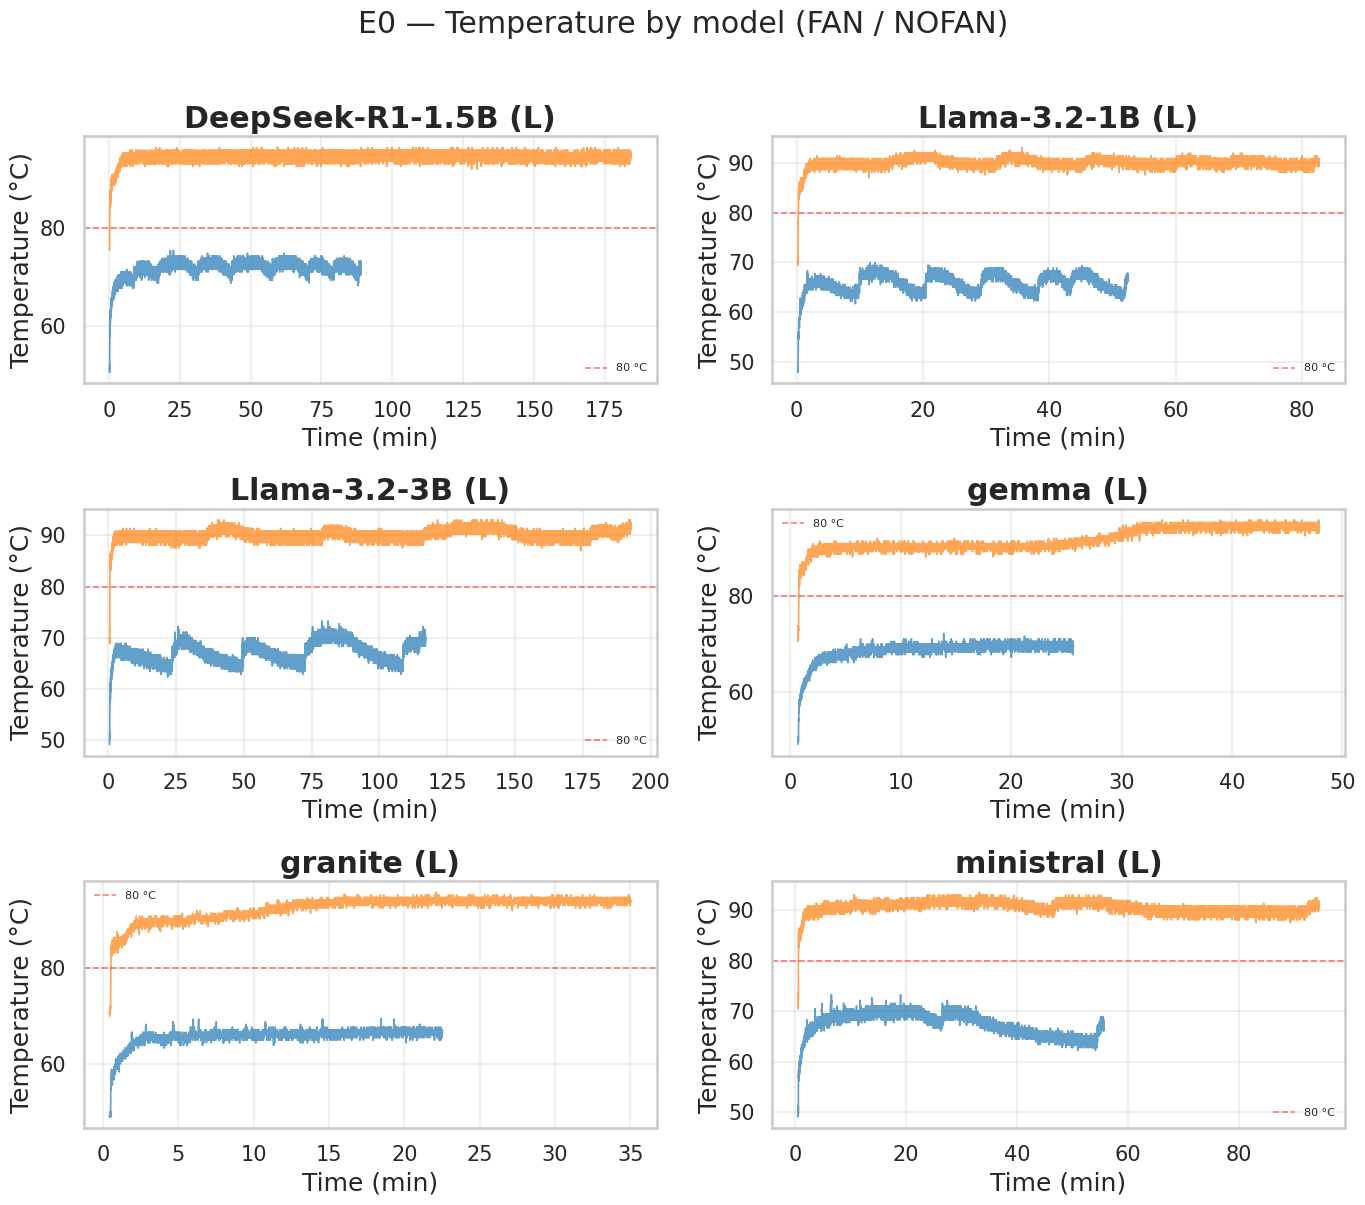

In [11]:
def _plot_timeline(hw_data, y_col, ylabel, suptitle, hline=None):
    models = sorted(hw_data['model_label'].unique())
    if not models:
        print(f'No data for {suptitle}')
        return
    ncols = 2
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        sub = hw_data[hw_data['model_label'] == model]
        if sub.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        t_max = sub['t_rel_s'].max()
        x_vals = sub['t_rel_s'] / 60 if t_max > 1800 else sub['t_rel_s']
        ax.set_xlabel('Time (min)' if t_max > 1800 else 'Time (s)')
        for rid in sub['run_id'].unique():
            s = sub[sub['run_id'] == rid].sort_values('t_rel_s')
            xv = s['t_rel_s'] / 60 if t_max > 1800 else s['t_rel_s']
            ax.plot(xv.values, s[y_col].values, alpha=0.7, lw=1.2)
        if hline is not None:
            ax.axhline(hline, ls='--', color='red', alpha=0.5, lw=1.2,
                       label=f'{hline} °C')
            ax.legend(fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight='bold')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _plot_timeline(hw_df, 'temperature_c', 'Temperature (°C)',
                   'E0 — Temperature by model (FAN / NOFAN)', hline=80)
else:
    print('No hardware data for temperature timelines.')


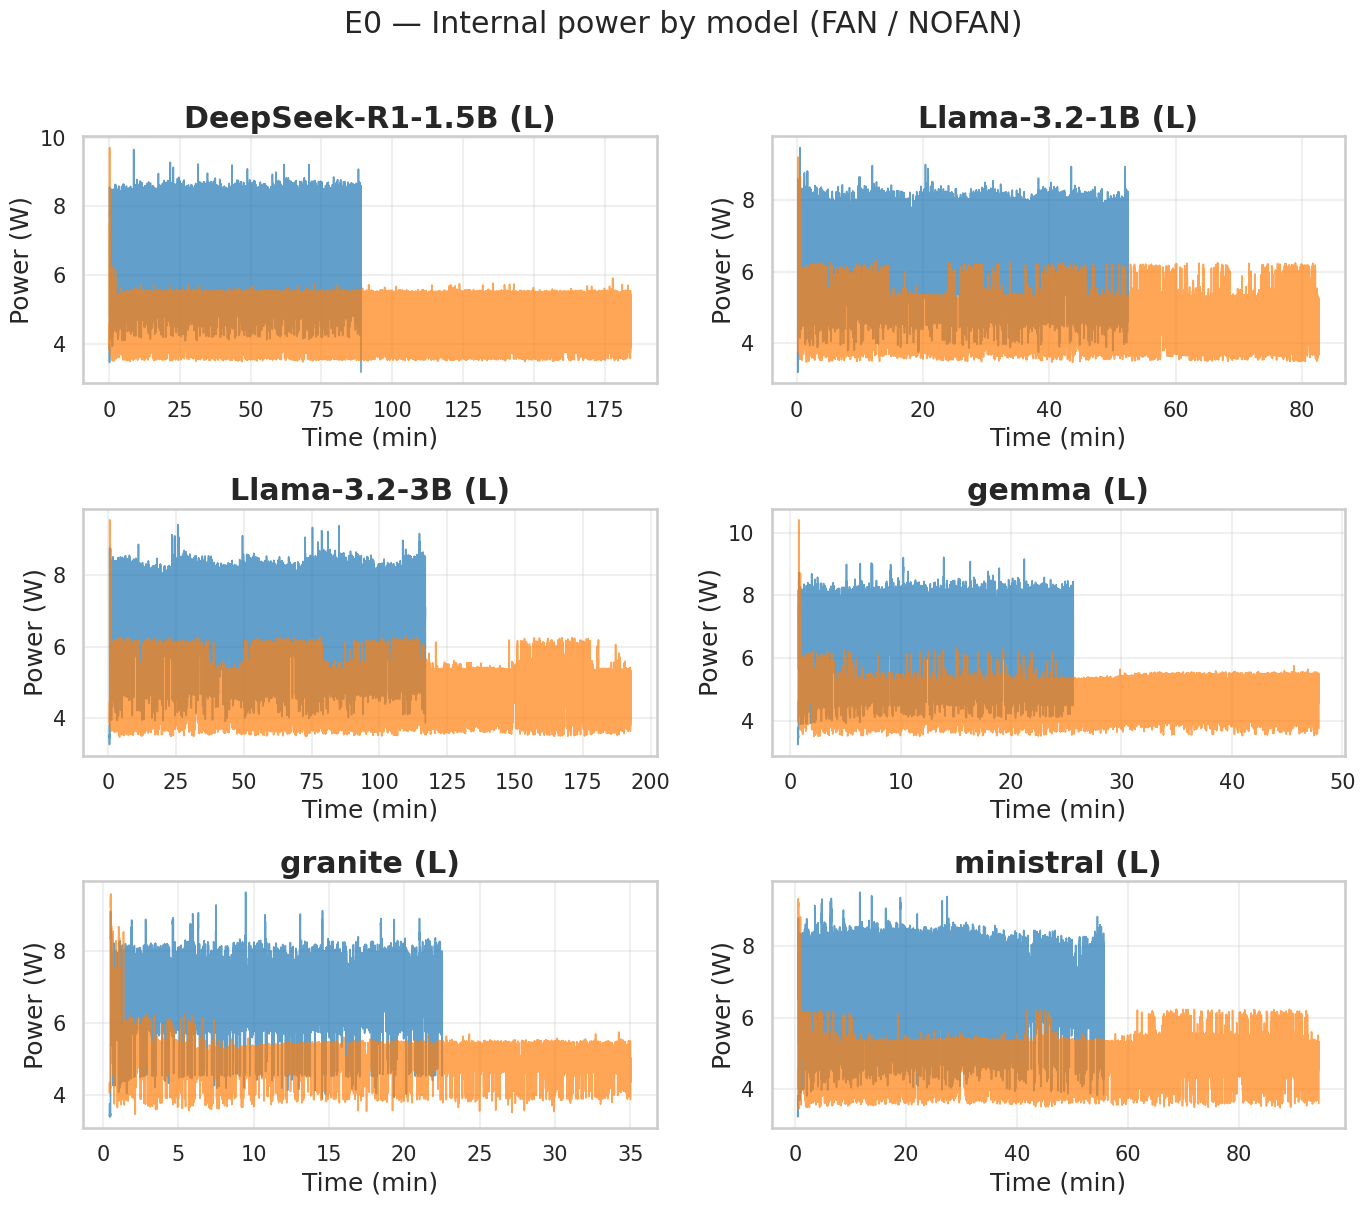

In [12]:
if not hw_df.empty:
    _plot_timeline(hw_df, 'internal_power_w', 'Power (W)',
                   'E0 — Internal power by model (FAN / NOFAN)')
else:
    print('No hardware data for power timelines.')


Representative run (most throttled): DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M


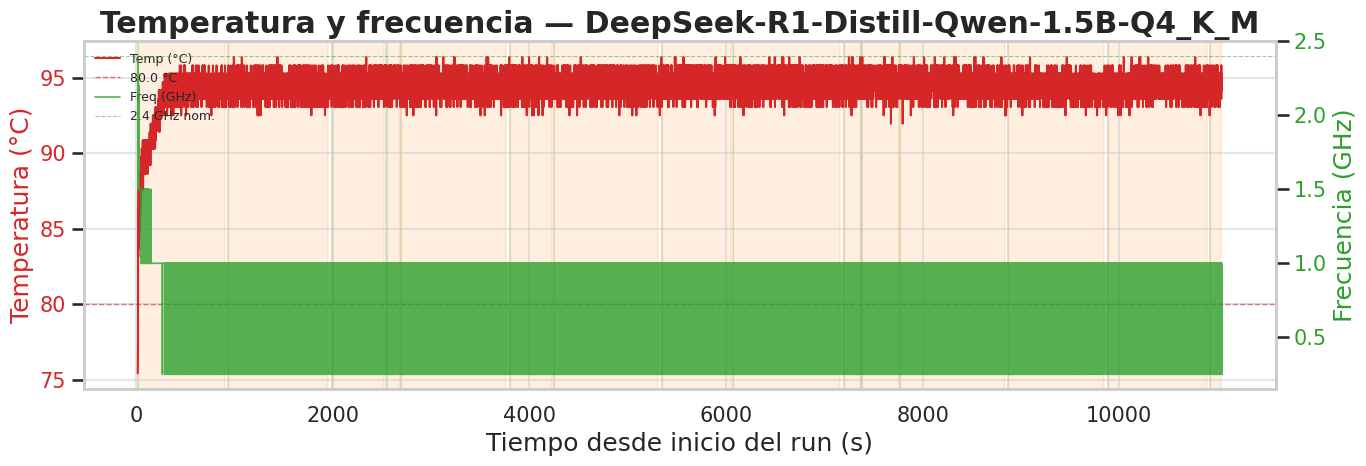

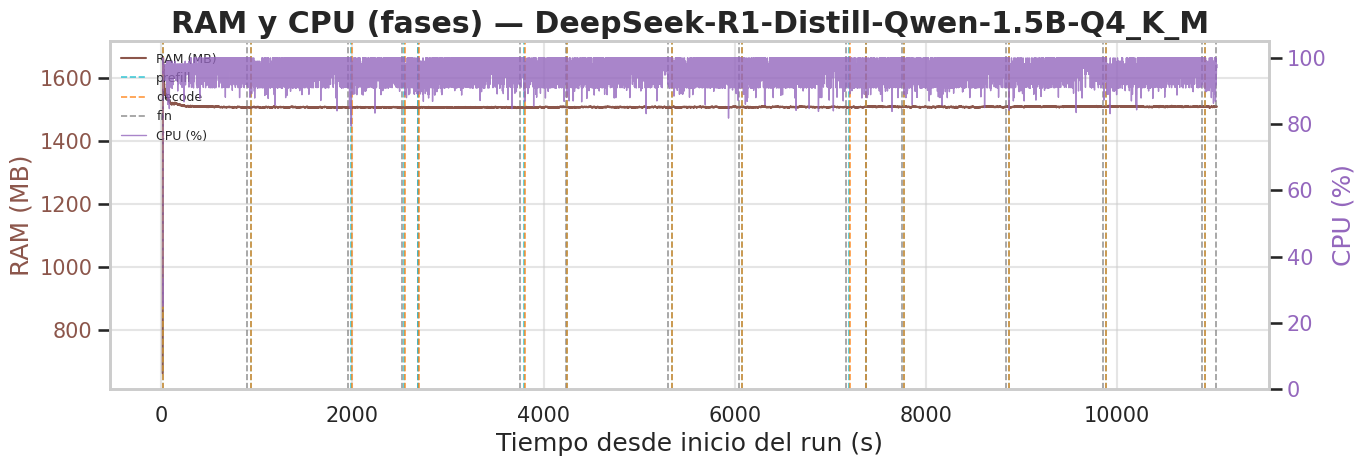

In [13]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _best = summary.sort_values('throttled_ratio', ascending=False)
    _rep_id = _best['run_id'].iloc[0] if 'run_id' in _best.columns else None
    if _rep_id:
        run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
        hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
        if run_rep is not None and not hw_rep.empty:
            print(f'Representative run (most throttled): {run_rep.model_short}')
            try:
                fig = temp_freq_dual(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'temp_freq_dual: {e}')
            try:
                fig = cpu_memory_dual_phases(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'cpu_memory_dual_phases: {e}')
        else:
            print('Representative run not found.')
    else:
        print('No run_id available.')
else:
    print('No hardware data or throttled_ratio for representative run.')


## 3. Hardware environment distributions

Statistical distributions of hardware metrics, aggregating all
samples from all runs in the experiment.


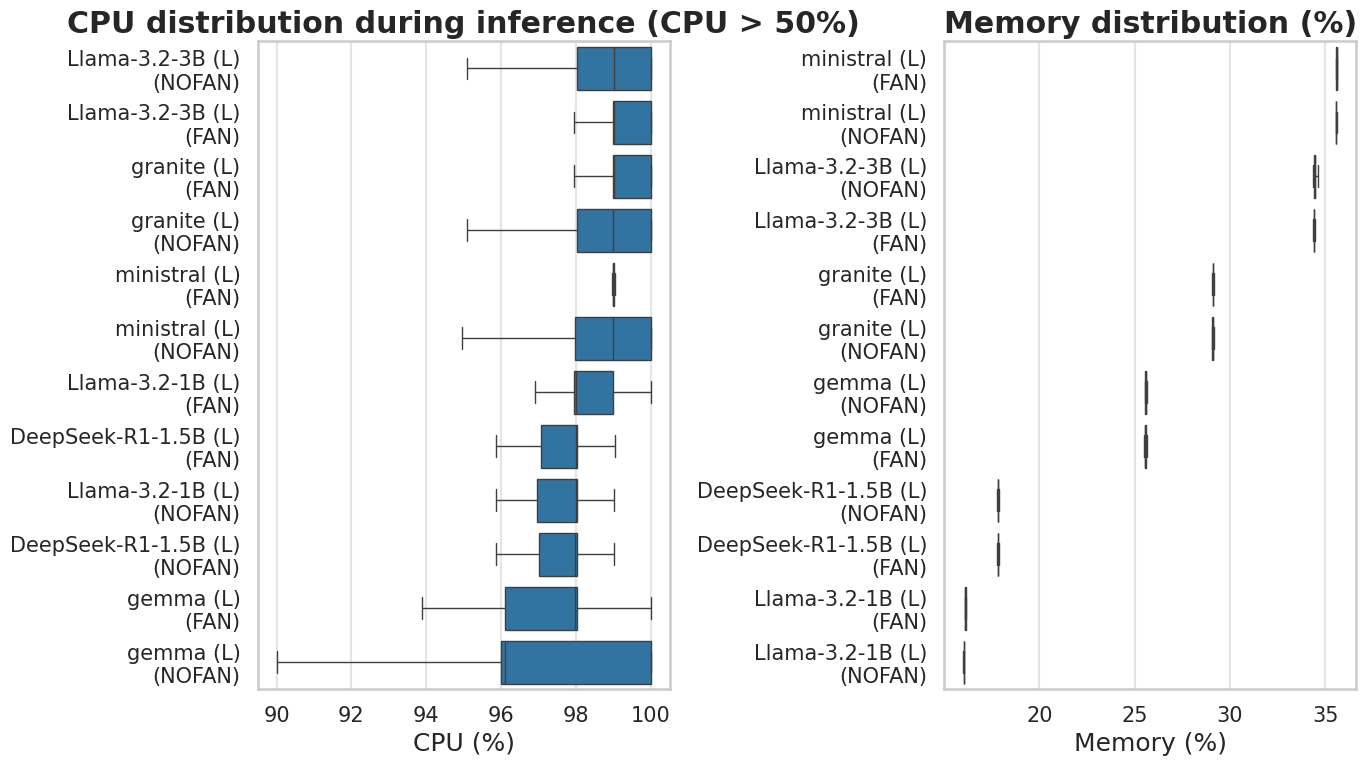

In [14]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    active = hw_df[hw_df['cpu_usage_pct'] > 50].copy()
    if not active.empty:
        order = (active.groupby(label_col)['cpu_usage_pct']
                 .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=active, y=label_col, x='cpu_usage_pct',
                    order=order, showfliers=False, ax=axes[0])
        axes[0].set_title('CPU distribution during inference (CPU > 50%)')
        axes[0].set_xlabel('CPU (%)')
        axes[0].set_ylabel('')
    if 'mem_pct' in hw_df.columns:
        order_mem = (hw_df.groupby(label_col)['mem_pct']
                     .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=hw_df, y=label_col, x='mem_pct',
                    order=order_mem, showfliers=False, ax=axes[1])
        axes[1].set_title('Memory distribution (%)')
        axes[1].set_xlabel('Memory (%)')
        axes[1].set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('No hardware data for boxplots.')


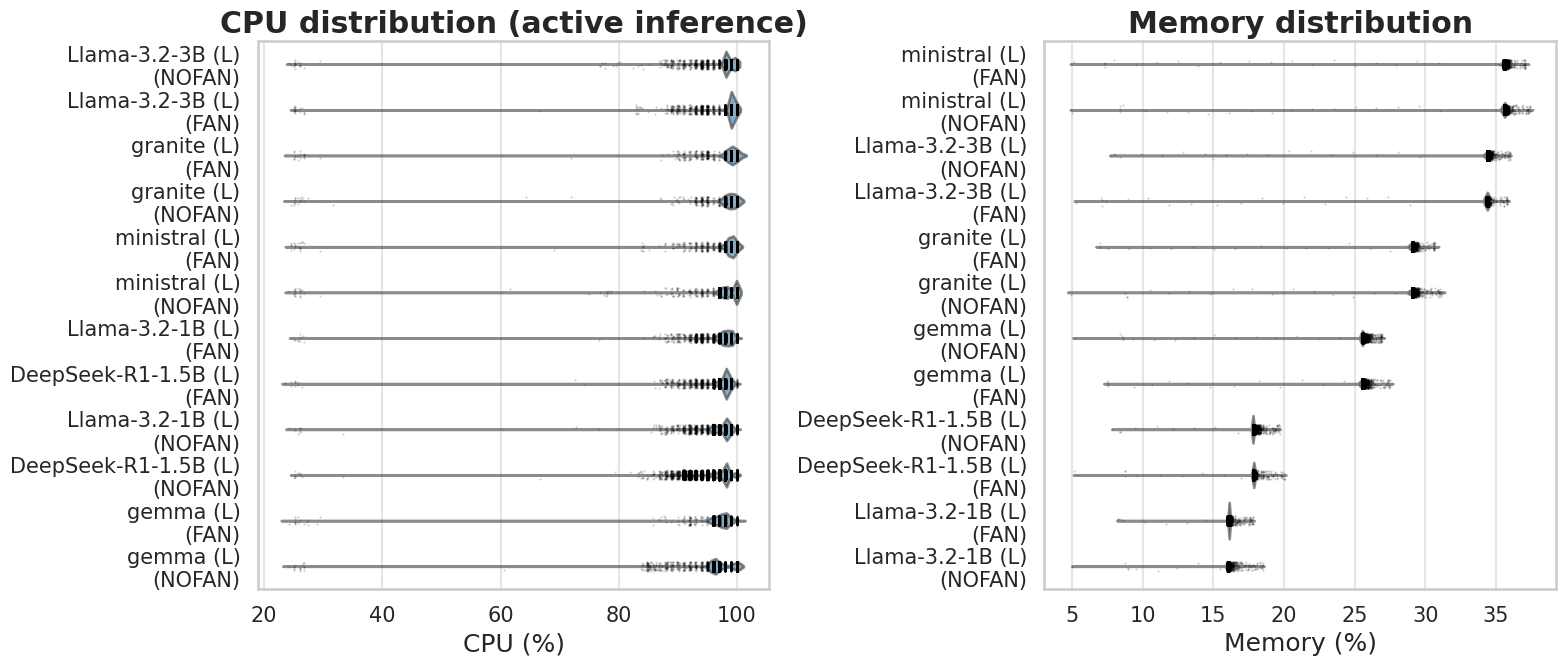

In [15]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (col, xlabel, title) in zip(axes, [
        ('cpu_usage_pct', 'CPU (%)',     'CPU distribution (active inference)'),
        ('mem_pct',       'Memory (%)',  'Memory distribution'),
    ]):
        if col not in hw_df.columns:
            ax.text(0.5, 0.5, f'{col} not available', ha='center', va='center',
                    transform=ax.transAxes); continue
        data = hw_df[hw_df['cpu_usage_pct'] > 10].copy() if 'cpu' in col else hw_df.copy()
        if data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes); continue
        order = (data.groupby(label_col)[col]
                 .median().sort_values(ascending=False).index.tolist())
        sns.violinplot(data=data, y=label_col, x=col,
                       order=order, inner=None, alpha=0.6, ax=ax)
        sns.stripplot(data=data, y=label_col, x=col,
                      order=order, size=1.5, alpha=0.2, color='black', ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('No hardware data for violin plots.')


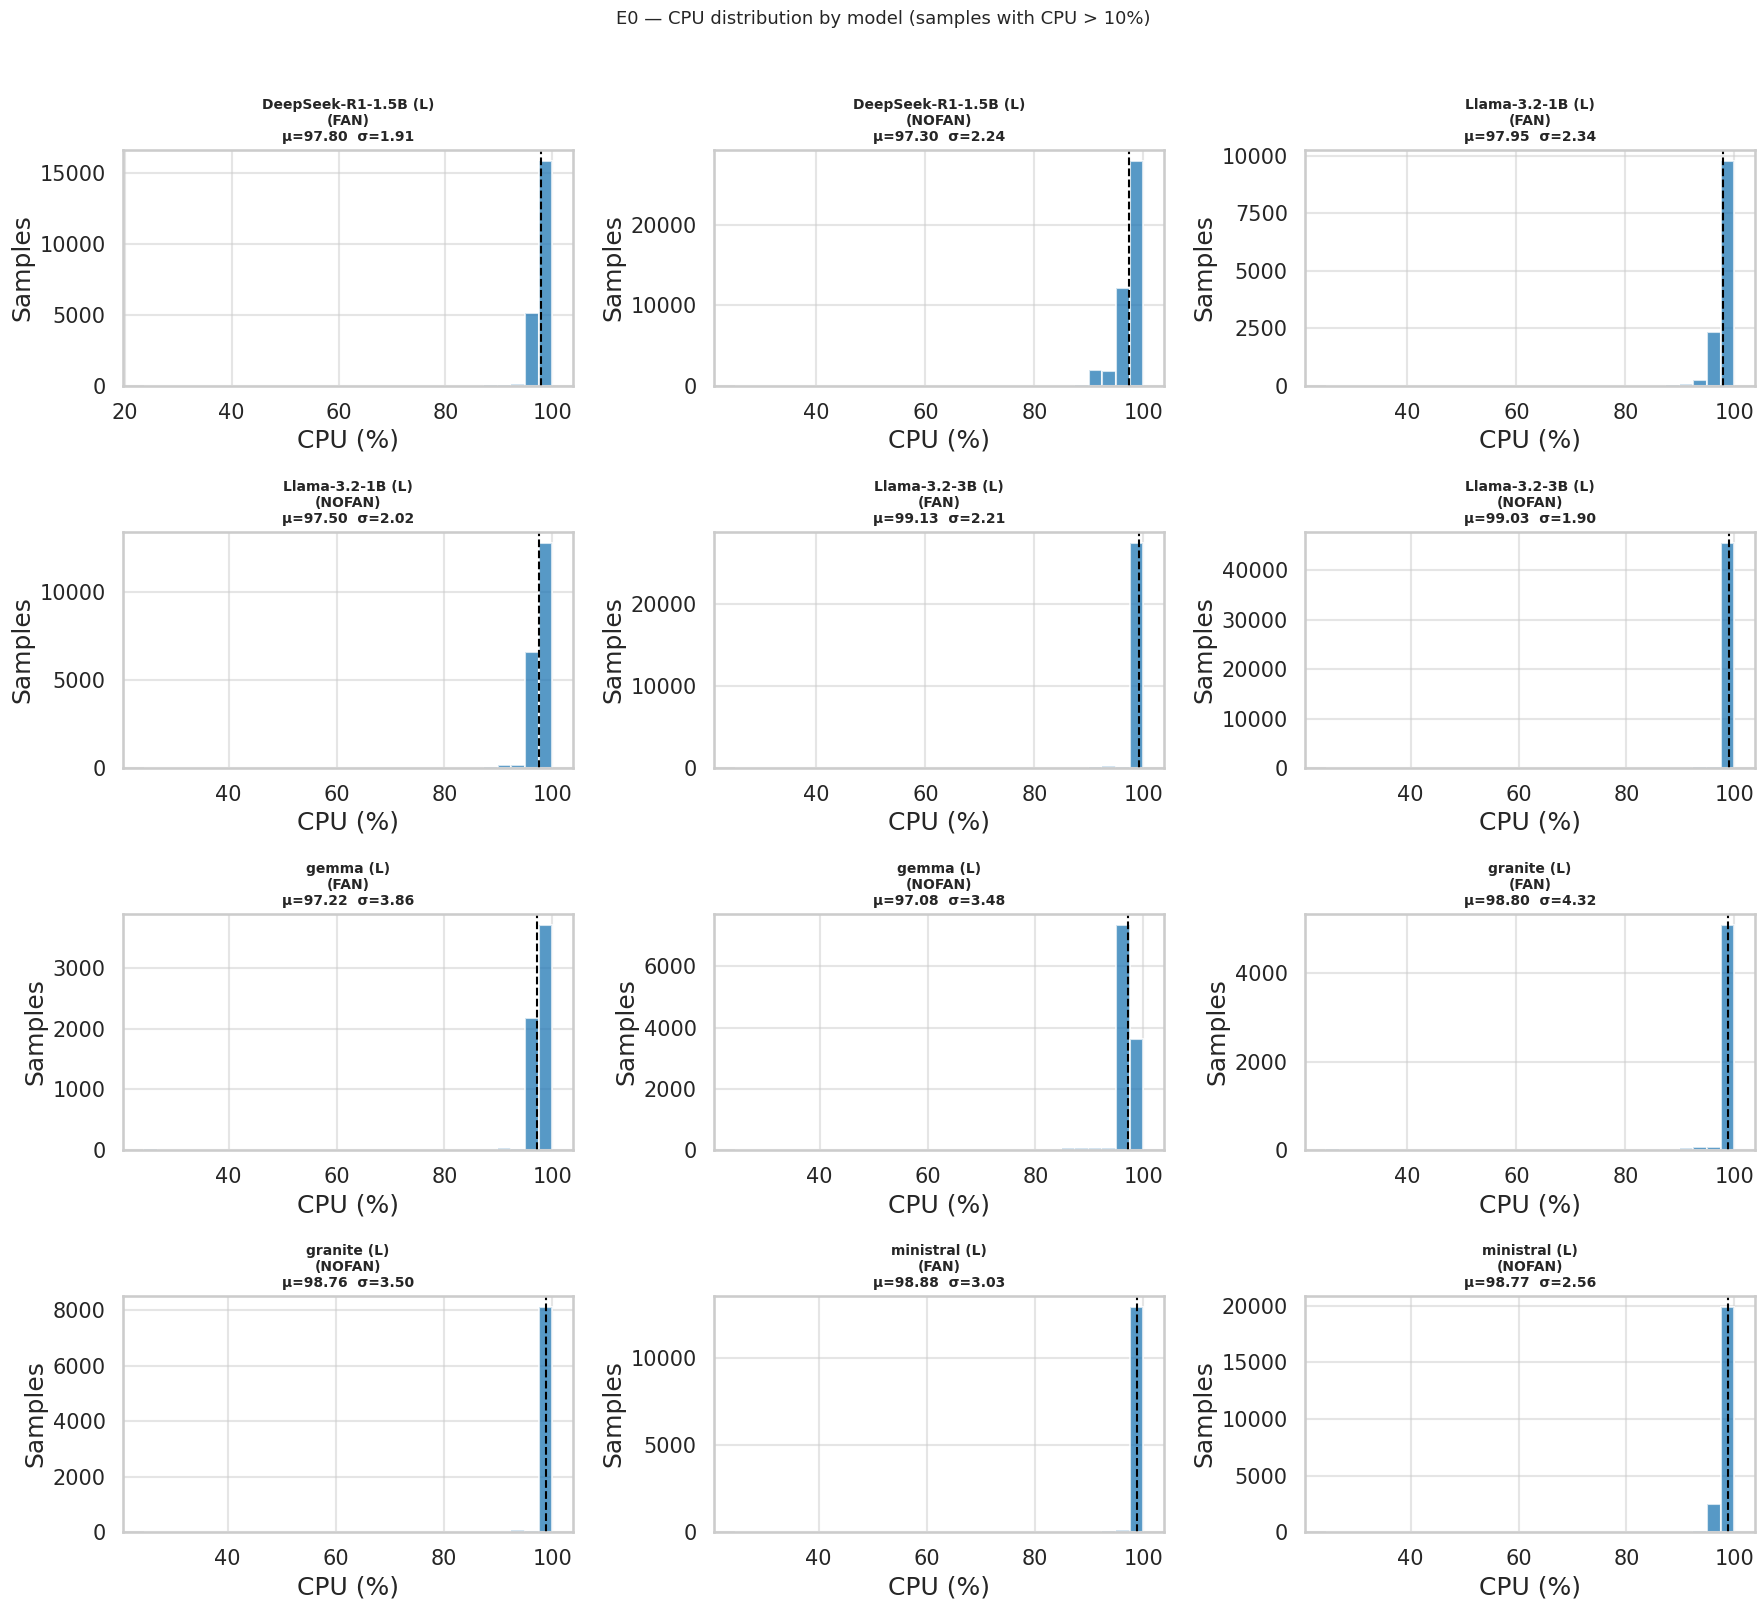

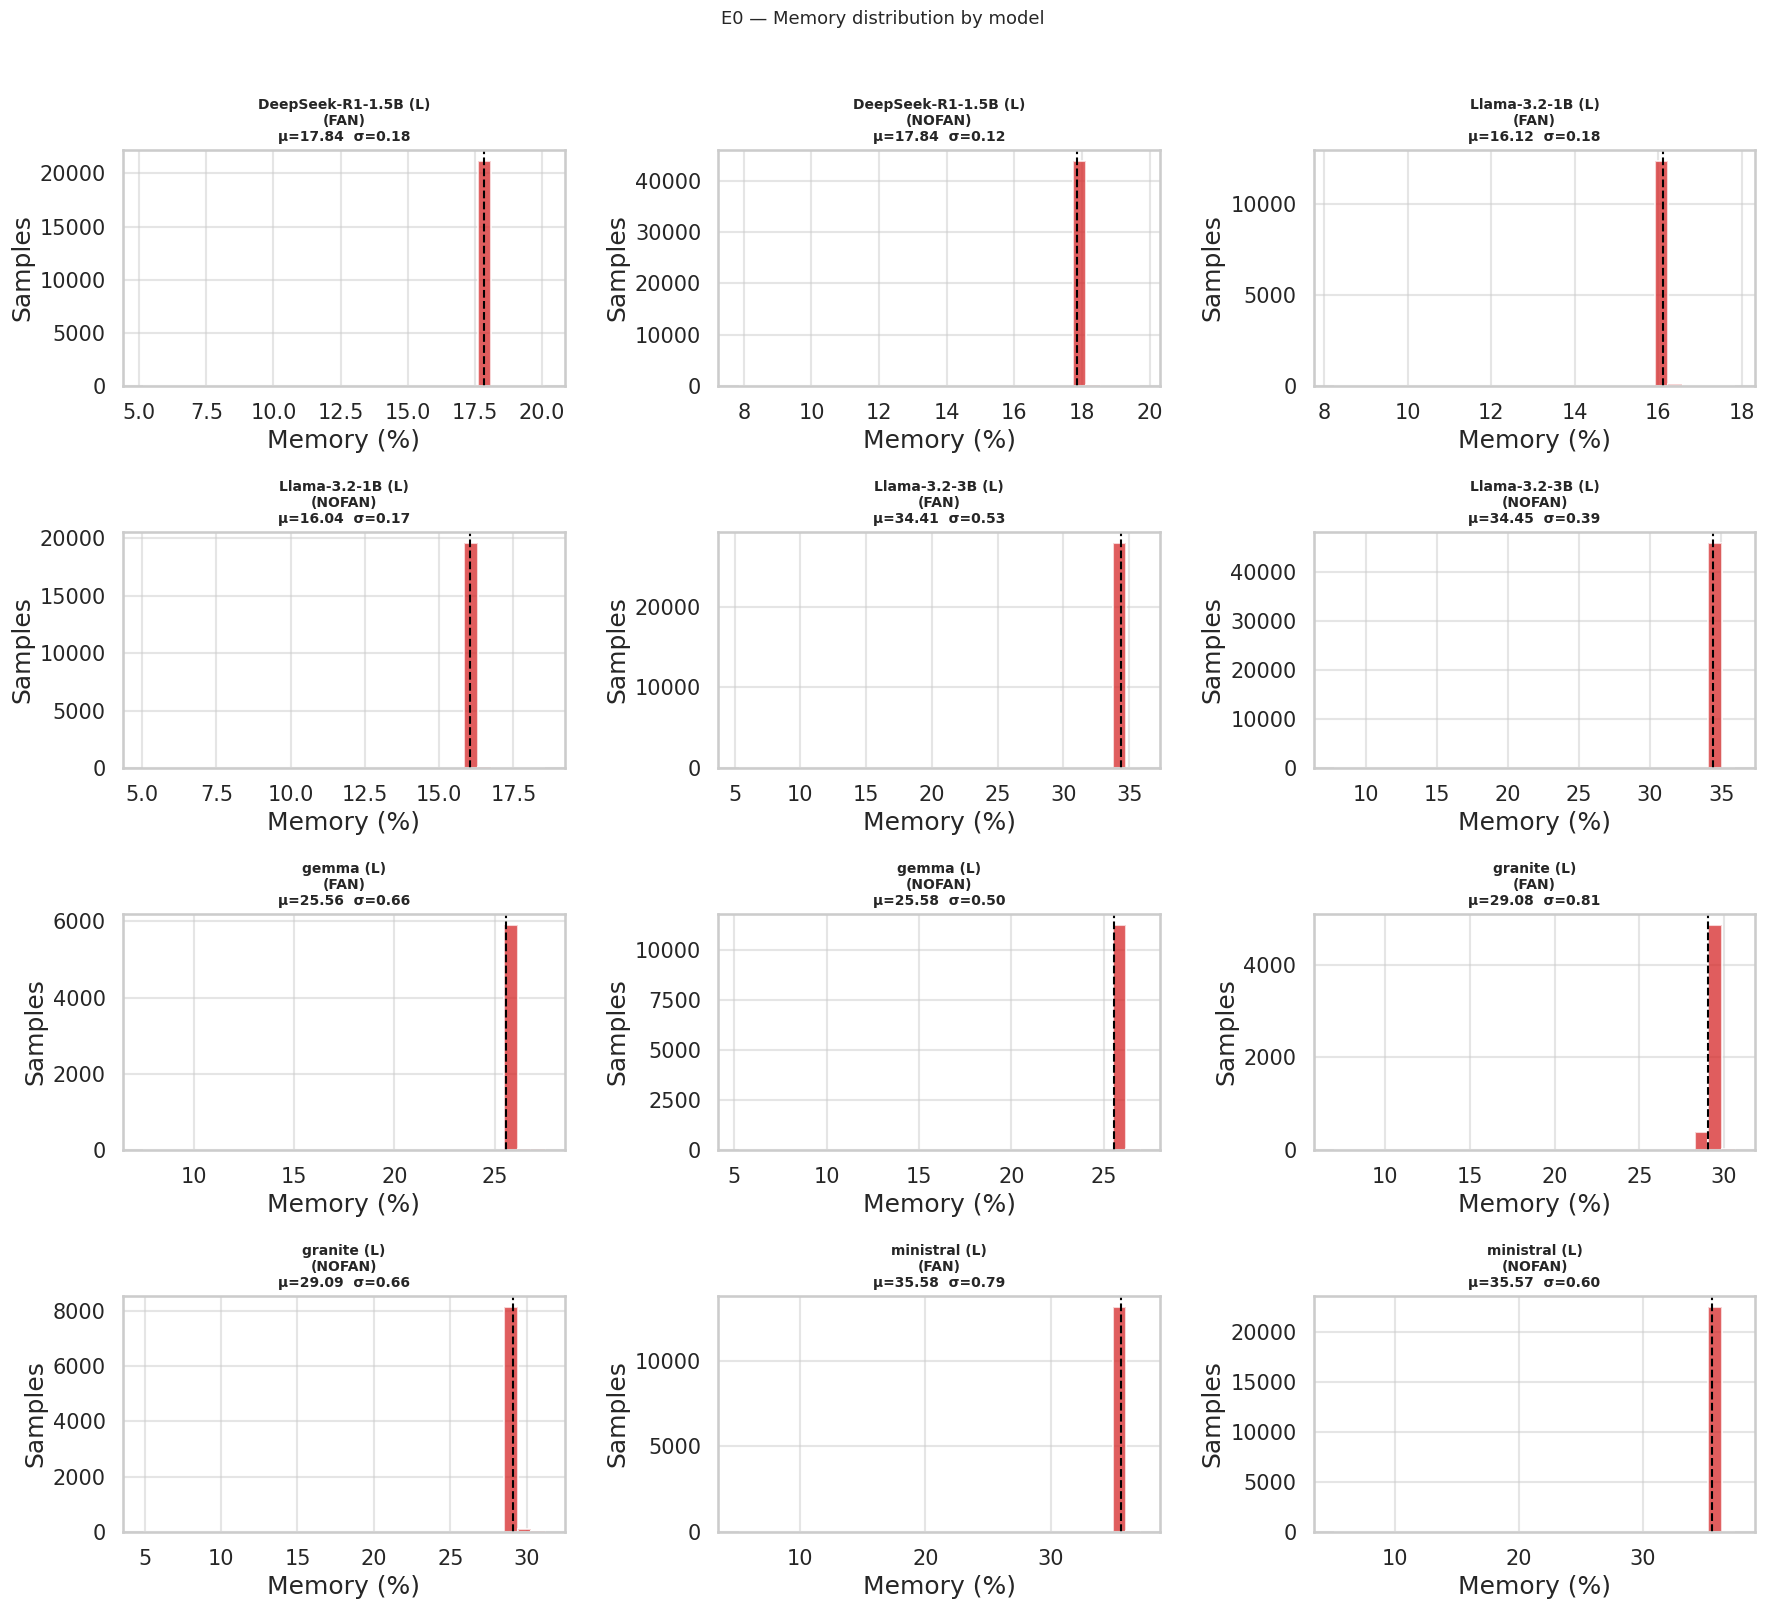

In [16]:
def _hist_by_model(hw_data, col, xlabel, color, suptitle,
                   xlim=None, vline=None):
    if col not in hw_data.columns:
        print(f'{col} not available'); return
    label_col = "config_label" if "config_label" in hw_data.columns else "model_label"
    models = sorted(hw_data[label_col].unique())
    ncols = 3
    nrows = -(-len(models) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             sharey=False)
    axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        ax = axes_flat[i]
        data = hw_data[hw_data[label_col] == model][col].dropna()
        if col == "cpu_usage_pct":
            data = data[data > 10]
        if data.empty:
            ax.set_visible(False); continue
        # Set an explicit range when xlim is defined to avoid NumPy's
        # automatic expansion when all values are equal
        hist_range = xlim if xlim else (data.min(), data.max())
        if hist_range[0] == hist_range[1]:
            hist_range = (hist_range[0] - 0.5, hist_range[1] + 0.5)
        ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white',
                range=hist_range)
        ax.axvline(data.mean(), color='black', ls='--', lw=1.5)
        if vline is not None:
            ax.axvline(vline, color='gray', ls=':', lw=1.2,
                       label=f'{vline} GHz nominal')
            ax.legend(fontsize=7)
        if xlim:
            ax.set_xlim(*xlim)
        ax.set_title(f"{model}\n\u03bc={data.mean():.2f}  \u03c3={data.std():.2f}",
                     fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Samples")
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _hist_by_model(hw_df, "cpu_usage_pct", "CPU (%)", "tab:blue",
                   "E0 \u2014 CPU distribution by model (samples with CPU > 10%)")
    _hist_by_model(hw_df, "mem_pct", "Memory (%)", "tab:red",
                   "E0 \u2014 Memory distribution by model")
else:
    print('No hardware data for histograms.')


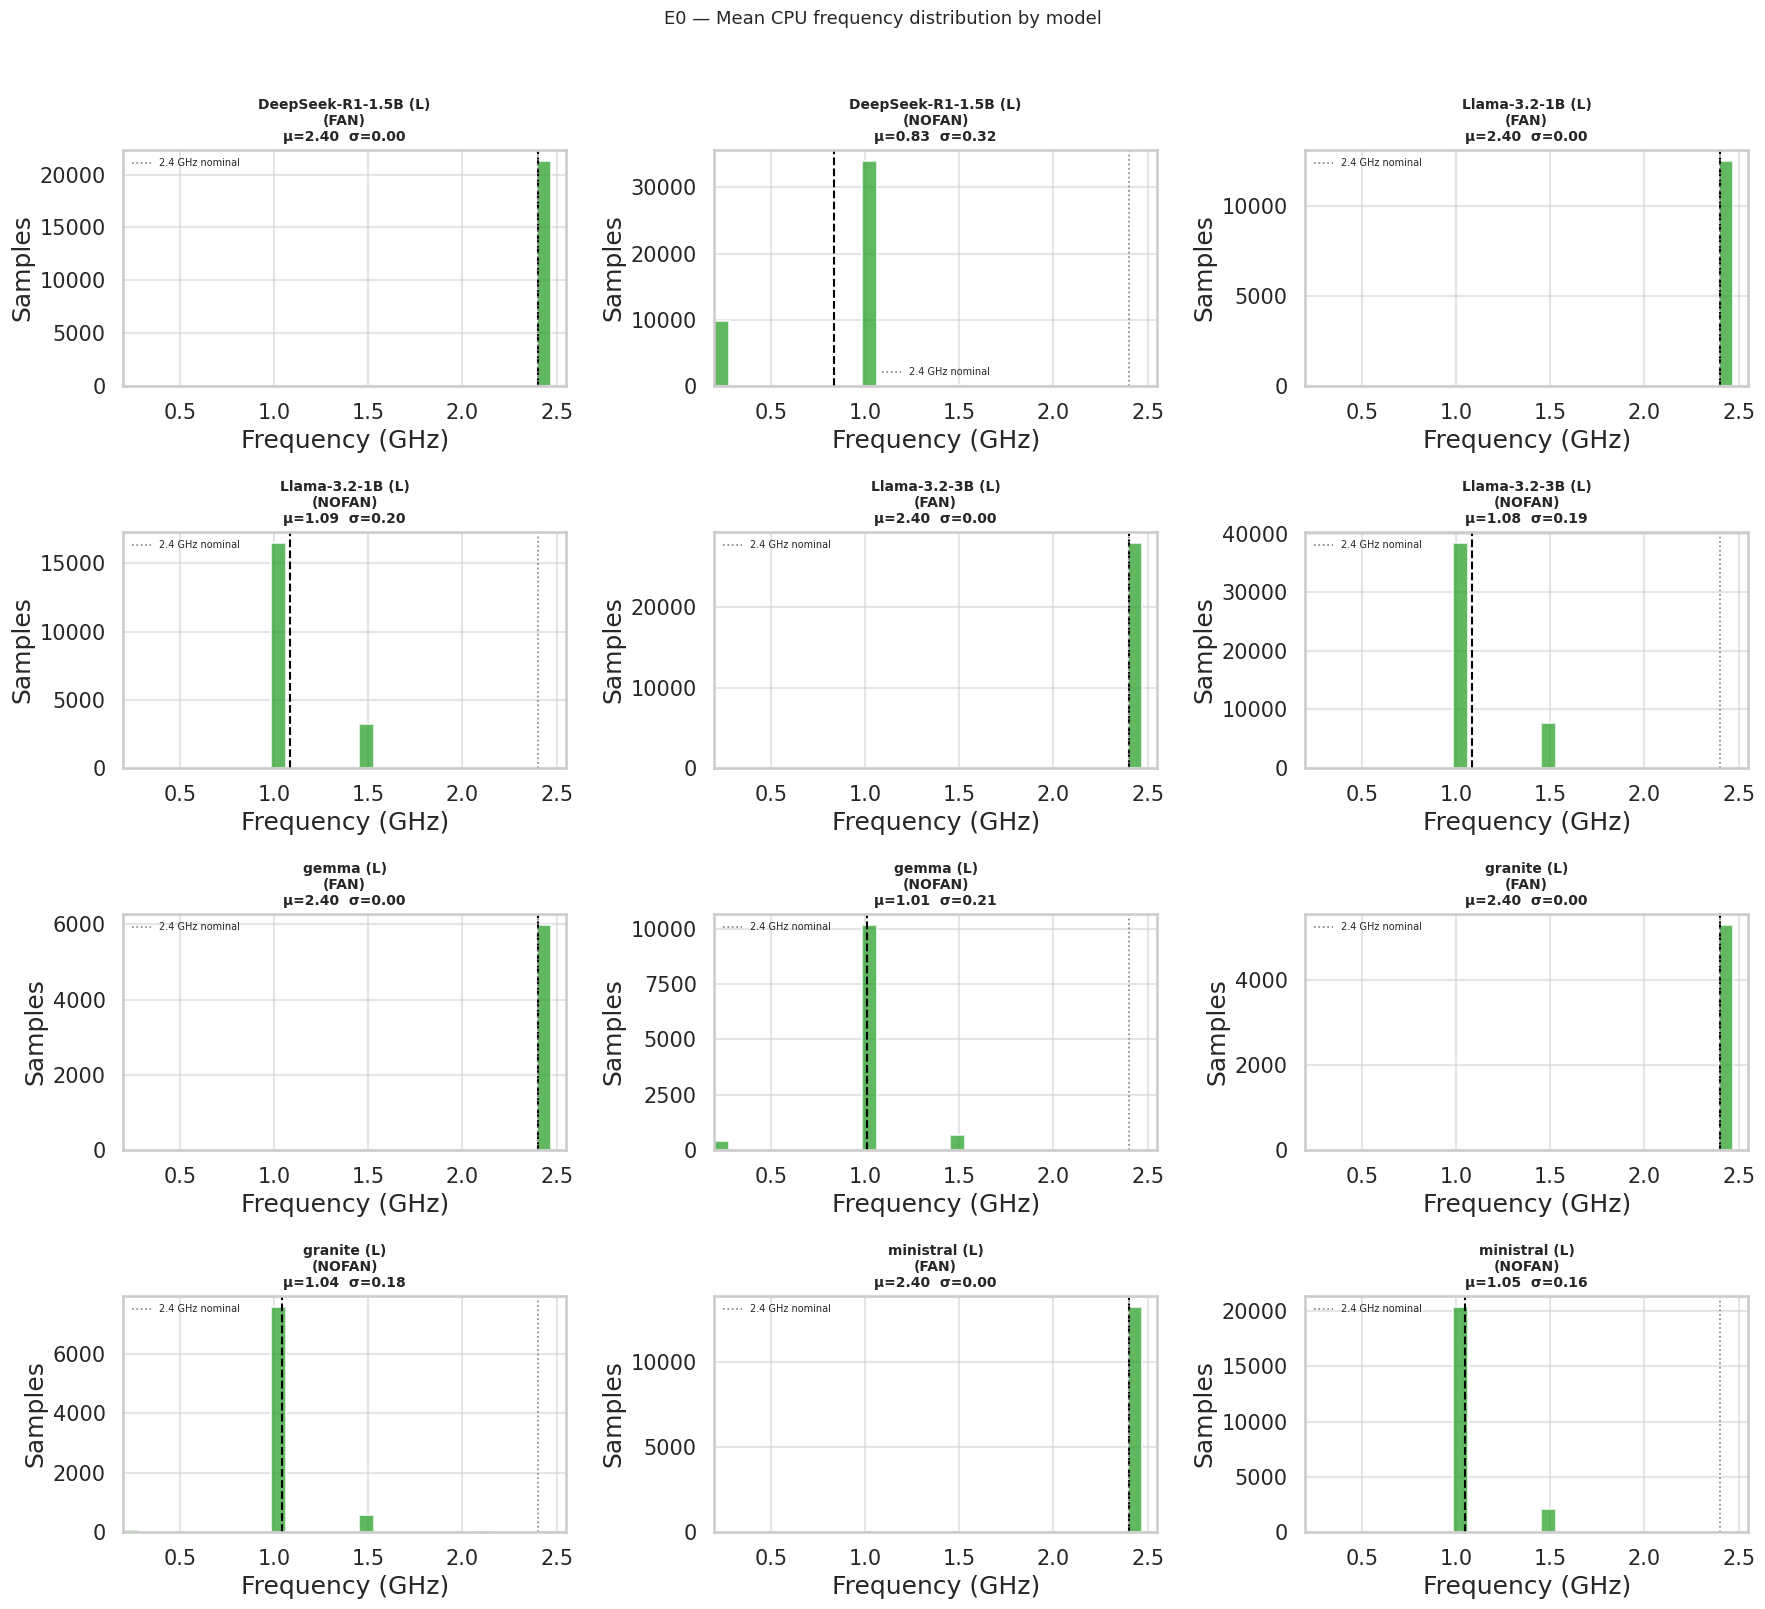

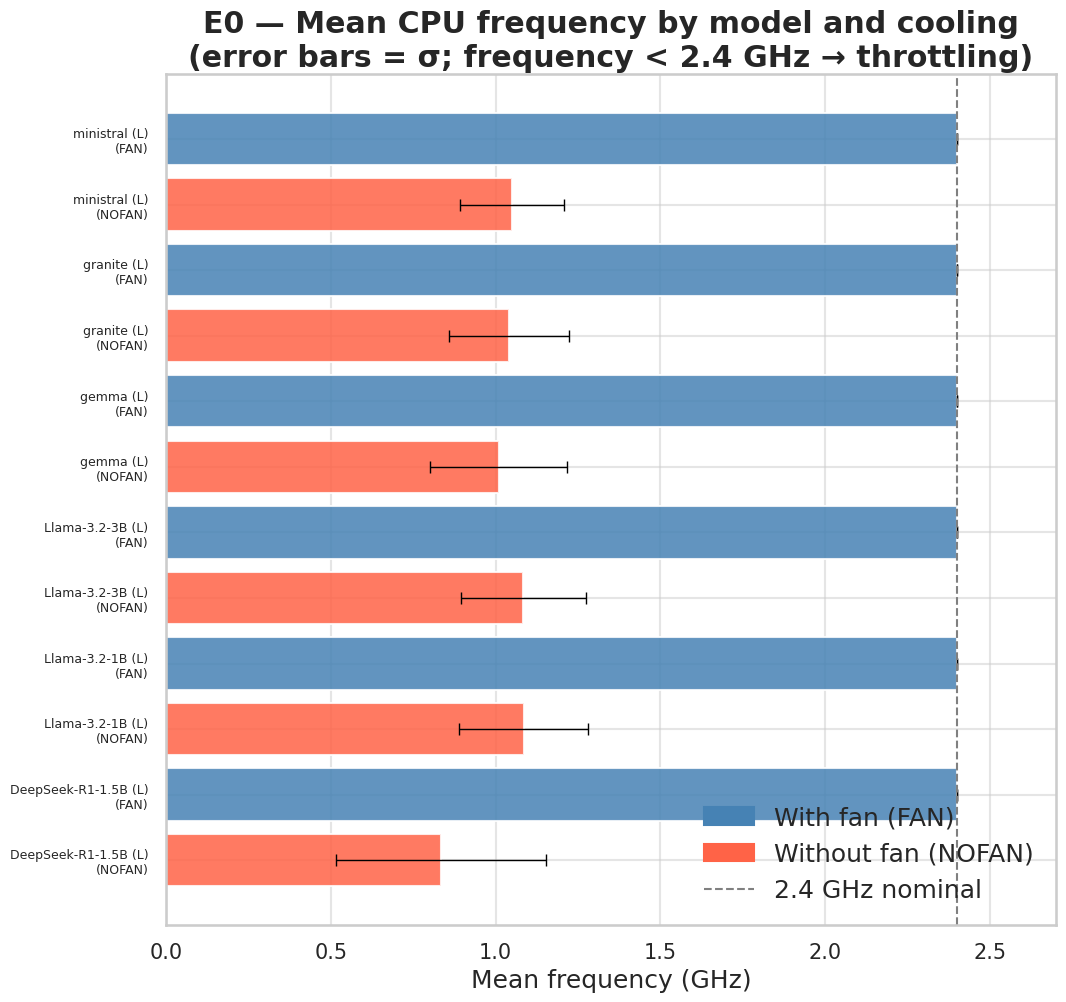


Mean frequency (GHz) during active inference:


,config,mean,std
0,DeepSeek-R1-1.5B (L)\n(NOFAN),0.835,0.318
1,DeepSeek-R1-1.5B (L)\n(FAN),2.400,0.000
2,Llama-3.2-1B (L)\n(NOFAN),1.085,0.196
3,Llama-3.2-1B (L)\n(FAN),2.400,0.000
4,Llama-3.2-3B (L)\n(NOFAN),1.084,0.190
5,Llama-3.2-3B (L)\n(FAN),2.400,0.000
6,gemma (L)\n(NOFAN),1.009,0.207
7,gemma (L)\n(FAN),2.400,0.000
8,granite (L)\n(NOFAN),1.040,0.183
9,granite (L)\n(FAN),2.400,0.000


In [17]:
if not hw_df.empty and 'freq_mean_ghz' in hw_df.columns:
    _hist_by_model(hw_df, "freq_mean_ghz", "Frequency (GHz)", "tab:green",
                   "E0 — Mean CPU frequency distribution by model",
                   xlim=(0.2, 2.55), vline=2.4)

    freq_summary = (hw_df[hw_df["cpu_usage_pct"] > 10]
                    .groupby(["model_label","fan"])["freq_mean_ghz"]
                    .agg(mean="mean", std="std")
                    .reset_index())
    if not freq_summary.empty:
        freq_summary["config"] = (
            freq_summary["model_label"] + "\n(" +
            freq_summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )
        freq_summary = freq_summary.sort_values(["model_label","fan"])

        n_bars  = len(freq_summary)
        fig_h   = max(6, n_bars * 0.9)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        bar_colors = freq_summary["fan"].map({True: "steelblue", False: "tomato"})
        ax.barh(freq_summary["config"], freq_summary["mean"],
                xerr=freq_summary["std"], color=bar_colors, alpha=0.85,
                capsize=4, error_kw={"elinewidth": 1, "ecolor": "black"})
        ax.axvline(2.4, ls='--', color='gray', lw=1.5)
        ax.set_xlim(0, 2.7)
        ax.set_xlabel("Mean frequency (GHz)")
        ax.set_title(
            "E0 — Mean CPU frequency by model and cooling\n"
            "(error bars = σ; frequency < 2.4 GHz → throttling)"
        )
        from matplotlib.patches import Patch
        import matplotlib.lines as mlines
        leg_elems = [
            Patch(color="steelblue", label="With fan (FAN)"),
            Patch(color="tomato",    label="Without fan (NOFAN)"),
            mlines.Line2D([],[],color='gray',ls='--',lw=1.5,label="2.4 GHz nominal"),
        ]
        ax.legend(handles=leg_elems, loc="lower right")
        ax.tick_params(axis='y', labelsize=9)
        plt.subplots_adjust(left=0.28)
        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
        plt.show()

        print("\nMean frequency (GHz) during active inference:")
        display(freq_summary[["config","mean","std"]].round(3))
else:
    print('freq_mean_ghz not available in hw_df.')


In [ ]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _rep_id = summary.sort_values('throttled_ratio', ascending=False)['run_id'].iloc[0]
    hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
    run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
    if run_rep is not None and not hw_rep.empty:
        try:
            fig = hw_distributions_panel(hw_rep, run_rep)
            plt.show()
        except Exception as e:
            print(f'hw_distributions_panel: {e}')
    else:
        print('Representative run not found for hw_distributions_panel.')
else:
    print('No data for hw histogram panel.')


In [ ]:
if not hw_df.empty and not pm_df.empty and not summary.empty:
    pm_valid_tmp = pm_df[~pm_df['is_empty_generation']].copy()

    hw_rows = []
    for _, row in summary.iterrows():
        rid   = row.get('run_id')
        fan_v = row.get('fan', False)
        hw_r  = hw_df[hw_df['run_id'] == rid] if rid else pd.DataFrame()
        pm_r  = pm_valid_tmp[pm_valid_tmp['run_id'] == rid] if rid else pd.DataFrame()
        if hw_r.empty: continue
        active_r = hw_r[hw_r['cpu_usage_pct'] > 50]
        hw_rows.append({
            'model_label': row['model_label'],
            'fan':    'FAN' if fan_v else 'NOFAN',
            'cpu_pct':  active_r['cpu_usage_pct'].mean() if not active_r.empty else float('nan'),
            'tokens_s': pm_r['tokens_per_second'].mean() if not pm_r.empty else float('nan'),
            'power_w':  hw_r['internal_power_w'].mean(),
            'mem_pct':  hw_r['mem_pct'].mean() if 'mem_pct' in hw_r.columns else float('nan'),
        })

    if hw_rows:
        from matplotlib.patches import Patch
        hw_sum  = pd.DataFrame(hw_rows)
        models  = sorted(hw_sum['model_label'].unique())
        y       = np.arange(len(models))
        width   = 0.35
        METRICS = [
            ('cpu_pct',  'Mean CPU (%)',        '(a)'),
            ('tokens_s', 'Throughput (tok/s)', '(b)'),
            ('power_w',  'Power (W)',            '(c)'),
            ('mem_pct',  'Memory (%)',           '(d)'),
        ]
        fig, axes = plt.subplots(2, 2, figsize=(14, max(8, len(models) * 1.1)))
        for ax, (col, xlabel, label) in zip(axes.flatten(), METRICS):
            for offset, fan_str, color in [
                (-width/2, 'FAN',   'steelblue'),
                ( width/2, 'NOFAN', 'tomato'),
            ]:
                vals = [
                    hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)][col].mean()
                    if not hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)].empty
                    else float('nan')
                    for m in models
                ]
                ax.barh(y + offset, vals, width, label=fan_str,
                        color=color, alpha=0.85)
            ax.set_yticks(y)
            ax.set_yticklabels(models, fontsize=9)
            ax.set_xlabel(xlabel)
            ax.set_title(f'{label} {xlabel}', fontweight='bold')
            ax.grid(True, axis='x', alpha=0.3)
            ax.legend(handles=[Patch(color='steelblue', label='FAN'),
                                Patch(color='tomato',   label='NOFAN')],
                      fontsize=8, loc='lower right')
        fig.suptitle('E0 \u2014 Metrics by model and cooling (FAN vs NOFAN)',
                     y=1.01)
        fig.tight_layout(); plt.show()
    else:
        print('No data for grouped bar chart.')
else:
    print('Not enough data for grouped bar chart.')


## 4. Inference metrics

Distribution of per-prompt performance metrics for each
experiment configuration.


In [ ]:
def _plot_metric(df, metric, ylabel='', title='', unit_label=''):
    """Horizontal barplot grouped by config_label when available."""
    label_col = 'config_label' if 'config_label' in df.columns else 'model_label'
    data = df.dropna(subset=[metric]).copy()
    if data.empty:
        print(f'No data for {metric}'); return
    means = data.groupby(label_col)[metric].mean().sort_values()
    full_title = f'{title}' + (f' ({unit_label})' if unit_label else '')
    fig, ax = plt.subplots(figsize=(10, max(4, len(means) * 0.55)))
    ax.barh(range(len(means)), means.values, alpha=0.85, color='steelblue')
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=9)
    ax.set_xlabel(unit_label or ylabel or metric)
    ax.set_title(full_title)
    ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    plt.show()


In [ ]:
pm_valid = pm_df[~pm_df['is_empty_generation']].copy() if not pm_df.empty else pd.DataFrame()

if not pm_valid.empty:
    if 'latency_ms' in pm_valid.columns:
        pm_valid['latency_s'] = pm_valid['latency_ms'] / 1000

    for metric, ylabel, unit in [
        ('tokens_per_second',      'tok/s', 'tokens/s'),
        ('words_per_second',       'words/s', 'words/s'),
        ('latency_s',              's',     'total latency per prompt'),
        ('time_to_first_token_ms', 'ms',    'TTFT — time to first token'),
        ('perplexity',             'PPL',   'PPL'),
    ]:
        if metric in pm_valid.columns:
            _plot_metric(pm_valid, metric, ylabel=ylabel,
                         title=f'E0 \u2014 {ylabel} by model', unit_label=unit)
        else:
            print(f'Metric not available: {metric}')
else:
    print('No valid prompts for inference metrics.')


In [ ]:
if not pm_valid.empty:
    hue_col   = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    ecdf_cols = [(c, lbl) for c, lbl in [
        ('latency_ms', 'Latency (ms)'),
        ('perplexity', 'Perplexity'),
    ] if c in pm_valid.columns]
    if ecdf_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        for ax, (col, xlabel) in zip(axes, ecdf_cols):
            sns.ecdfplot(data=pm_valid.dropna(subset=[col]),
                         x=col, hue=hue_col, ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Cumulative proportion')
            ax.set_title(f'ECDF \u2014 {xlabel}')
            lgd = ax.get_legend()
            if lgd:
                lgd.set_title("Legend")
                lgd.set_bbox_to_anchor((1.02, 1))
                lgd.set_loc('upper left')
                for txt in lgd.get_texts():
                    txt.set_fontsize(7)
        # Hide the second ax if there's only one ECDF
        if len(ecdf_cols) == 1:
            axes[1].set_visible(False)
        fig.tight_layout()
        plt.show()
else:
    print('No data for ECDFs.')


In [ ]:
if not pm_valid.empty and 'eval_count' in pm_valid.columns:
    label_col = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    models = sorted(pm_valid[label_col].unique())
    ncols = min(4, len(models))
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        if i >= len(axes_flat):
            break
        ax = axes_flat[i]
        data = pm_valid[pm_valid[label_col] == model]['eval_count'].dropna()
        ax.hist(data, bins=15, color=f'C{i}', alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), ls='--', color='black', lw=1.5,
                   label=f'\u03bc={data.mean():.0f}')
        ax.set_title(f'{model} (n={len(data)})', fontsize=9)
        ax.set_xlabel('tokens generated')
        ax.legend(fontsize=8)
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Response length distribution by model', y=1.01)
    fig.tight_layout()
    plt.show()

    print('\nSummary (tokens generated):')
    display(pm_valid.groupby(label_col)['eval_count']
            .agg(['count', 'mean', 'std', 'min', 'max']).round(1))
else:
    print('No data for response length distribution.')


## 5. Energy efficiency and effective CPU work

**W_CPU (core·s)**: effective computational work = ∫(f(t)/f_nom)·(CPU(t)/100)·N_cores·dt.
Analogous to "person-hour". With throttling at 50% frequency, W_CPU is
half what it would be at nominal frequency over the same wall-clock time.

**η_CPU**: CPU efficiency = W_CPU / (N_cores·T). Range [0,1].

**W_token (core·s/token)**: computational cost per generated token.


In [ ]:
if not summary.empty:
    for metric, title, unit in [
        ('energy_per_token_j',  'Energy per token',            'J/token'),
        ('cpu_work_core_s',     'Effective CPU work (W_CPU)',   'core·s'),
        ('cpu_efficiency',      'CPU efficiency (η_CPU)',       ''),
        ('cpu_work_per_token',  'CPU work per token',           'core·s/token'),
    ]:
        if metric in summary.columns:
            _plot_metric(summary, metric, ylabel=unit,
                         title=f'E0 \u2014 {title}', unit_label=unit)
        else:
            print(f'Metric not available in summary: {metric}')
else:
    print('No summary data for energy efficiency.')


In [ ]:
# Reusable scatter helpers for the notebook
MARKERS    = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<"]
COLORS_FAN = {True: "steelblue", False: "tomato"}
LABELS_FAN = {True: "FAN", False: "NOFAN"}
OFFSETS    = [(5,5),(-5,-10),(10,-5),(-10,5),(5,-15),(-5,10),
              (15,0),(-15,0),(0,12),(-12,-5),(8,-8),(-8,8)]

def scatter_with_legend(ax, data, x, y, label_col="model_label", fan_col="fan"):
    models    = sorted(data[label_col].unique())
    marker_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    seen = set()
    for _, row in data.iterrows():
        model = row[label_col]; fan = row.get(fan_col, True); key = (model, fan)
        lbl = f"{model} ({LABELS_FAN.get(fan, str(fan))})" if key not in seen else None
        ax.scatter(row[x], row[y], marker=marker_map[model],
                   color=COLORS_FAN.get(fan, "gray"), s=150, zorder=3, label=lbl)
        seen.add(key)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8,
              title="Model (cooling)", framealpha=0.9)
    ax.grid(True, alpha=0.3)

def scatter_cpu_energy(ax, df, x_col, y_col, x_label, y_label, title):
    models  = sorted(df["model_label"].unique())
    mk_map  = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    for idx, (_, row) in enumerate(df.iterrows()):
        if pd.isna(row.get(x_col)) or pd.isna(row.get(y_col)): continue
        m, fan = row["model_label"], row["fan"]
        ax.scatter(row[x_col], row[y_col],
                marker=mk_map[m], color=COLORS_FAN[fan],

                   s=200, zorder=3, edgecolors='black', linewidths=0.5)
        ox, oy = OFFSETS[idx % len(OFFSETS)]
        # ax.annotate(
        #     f"{m}\n({LABELS_FAN[fan]})",
        #     xy=(row[x_col], row[y_col]),
        #     xytext=(ox, oy), textcoords="offset points",
        #     fontsize=7, ha='center',
        #     arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        # )
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_title(title); ax.grid(True, alpha=0.3)

if not summary.empty:
    cpu_e = summary.dropna(subset=["cpu_work_core_s", "power_mean_w"]).copy()
    if not cpu_e.empty:
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        scatter_cpu_energy(axes[0], cpu_e,
            "power_mean_w",    "cpu_work_core_s",
            "Mean power (W)", "W_CPU (core\u00b7s)", "CPU work vs Power")
        scatter_cpu_energy(axes[1], cpu_e,
            "power_mean_w",    "cpu_efficiency",
            "Mean power (W)", "\u03b7_CPU", "CPU efficiency vs Power")
        scatter_cpu_energy(axes[2], cpu_e,
            "cpu_work_core_s", "energy_per_token_j",
            "W_CPU (core\u00b7s)", "Energy/token (J)", "CPU work per token")
        from matplotlib.lines import Line2D
        models = sorted(cpu_e["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue","With fan (FAN)"),
                           ("tomato",  "Without fan (NOFAN)")]]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models)+2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.12), title="Model | Cooling")
        fig.suptitle("E0 \u2014 Relationship between effective CPU work and energy consumption")
        fig.tight_layout(); plt.show()
    else:
        print('Not enough data for CPU vs Power charts.')
else:
    print('No summary data for CPU vs Power analysis.')


## 6. Combined performance and hardware utilization


In [ ]:
# MBU_corr — Memory Bandwidth Utilization (architecture-corrected)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col = "mbu_corr" if "mbu_corr" in summary.columns else (
           "mbu_pct"  if "mbu_pct"  in summary.columns else None)

if _mbu_col is not None:
    mbu_data = summary.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = (
            [(True, "With fan (FAN)", "steelblue"),
             (False, "Without fan (NOFAN)", "tomato")]
            if has_fan else [(None, "MBU_corr", "steelblue")]
        )
        fig, axes = plt.subplots(1, len(fan_groups),
                                  figsize=(7 * len(fan_groups), 5), sharey=False)
        if len(fan_groups) == 1:
            axes = [axes]
        for ax, (fan_val, lbl, color) in zip(axes, fan_groups):
            sub = (mbu_data[mbu_data["fan"] == fan_val]
                   if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                ax.set_axis_off(); continue
            ax.barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            ax.axvline(100, ls="--", color="gray", alpha=0.5)
            ax.set_xlabel("MBU_corr (%)")
            ax.set_title(lbl)
            ax.grid(True, axis="x", alpha=0.3)
            for bar, val in zip(ax.patches, sub[_mbu_col]):
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", va="center", fontsize=9)
        fig.suptitle(
            f"E0 — MBU_corr: actual bandwidth utilization\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, 32-bit bus)\n"
            "† gemma3n: upper bound (selective activation, actual MBU_corr < theoretical)",
            fontsize=10)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (mbu_data[["model_label","mbu_corr","mbu_corr_notes"]]
                     .drop_duplicates("model_label").round(2))
            print("Corrections applied:")
            display(notes)
else:
    print("mbu_corr not available for this experiment.")


In [ ]:
if not hw_df.empty:
    runs_con_hw = [r for r in coll.runs
                   if not hw_df[hw_df['run_id'] == r.run_id].empty]
    if runs_con_hw:
        try:
            fig = throttling_heatmap(hw_df, runs_con_hw,
                                     title='E0 \u2014 Throttling events per run')
            plt.show()
        except Exception as e:
            print(f'throttling_heatmap: {e}')
    else:
        print('No runs with hardware data for throttling heatmap.')
else:
    print('No hardware data for throttling heatmap.')


In [ ]:
if not summary.empty:
    phase_cols = {}
    for run in coll.runs:
        rid   = run.run_id
        label = summary.loc[summary["run_id"] == rid, "model_label"].values
        fan   = summary.loc[summary["run_id"] == rid, "fan"].values
        if len(label) == 0: continue
        non_empty = [p for p in run.prompts if not p.is_empty_generation]
        if not non_empty: continue
        phase_cols.setdefault("model_label", []).append(label[0])
        phase_cols.setdefault("fan",         []).append(fan[0])
        # Mean per prompt
        phase_cols.setdefault("load_s",      []).append(
            np.mean([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_s",   []).append(
            np.mean([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_s",    []).append(
            np.mean([p.eval_duration_ns / 1e9 for p in non_empty]))
        # Total run (sum over all prompts)
        phase_cols.setdefault("load_total_s",    []).append(
            np.sum([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_total_s", []).append(
            np.sum([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_total_s",  []).append(
            np.sum([p.eval_duration_ns / 1e9 for p in non_empty]))

    phase_df2 = pd.DataFrame(phase_cols)
    if not phase_df2.empty:
        phase_df2["config"] = (
            phase_df2["model_label"] + " (" +
            phase_df2["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )

    PHASES       = ["load_s",       "prefill_s",       "decode_s"]
    PHASES_TOTAL = ["load_total_s", "prefill_total_s", "decode_total_s"]
    LABELS  = {"load_s": "Load", "prefill_s": "Prefill", "decode_s": "Decode",
               "load_total_s": "Load", "prefill_total_s": "Prefill", "decode_total_s": "Decode"}
    COLORS  = {"load_s": "#bcbd22", "prefill_s": "#17becf", "decode_s": "#ff7f0e",
               "load_total_s": "#bcbd22", "prefill_total_s": "#17becf", "decode_total_s": "#ff7f0e"}

    if not phase_df2.empty:
        n_configs = len(phase_df2)
        fig, axes = plt.subplots(1, 3, figsize=(24, max(5, n_configs * 0.55)))

        # Panel 1: Proportion (%) — uses totals for the real proportion
        ax = axes[0]
        total_run = phase_df2[PHASES_TOTAL].sum(axis=1)
        left = np.zeros(n_configs)
        for ph, ph_t in zip(PHASES, PHASES_TOTAL):
            vals = phase_df2[ph_t] / total_run * 100
            ax.barh(phase_df2["config"], vals, left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += vals.to_numpy()
        ax.set_title("Proportion (%) by phase")
        ax.set_xlim(0, 105); ax.set_xlabel("%")
        ax.set_ylabel(""); ax.legend(title="Phase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 2: Mean per prompt (s)
        ax = axes[1]
        left = np.zeros(n_configs)
        for ph in PHASES:
            ax.barh(phase_df2["config"], phase_df2[ph], left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += phase_df2[ph].to_numpy()
        ax.set_title("Mean per prompt (s)")
        ax.set_xlabel("Seconds"); ax.set_ylabel("")
        ax.legend(title="Phase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 3: Total run (s)
        ax = axes[2]
        left = np.zeros(n_configs)
        for ph_t in PHASES_TOTAL:
            ax.barh(phase_df2["config"], phase_df2[ph_t], left=left,
                    label=LABELS[ph_t], color=COLORS[ph_t], alpha=0.85, height=0.6)
            left += phase_df2[ph_t].to_numpy()
        ax.set_title("Total run duration (s)")
        ax.set_xlabel("Seconds"); ax.set_ylabel("")
        ax.legend(title="Phase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        fig.suptitle("E0 \u2014 Temporal breakdown of inference phases", fontsize=13)
        fig.tight_layout(); plt.show()
    else:
        print("No phase data.")
else:
    print("No summary data for phase breakdown.")
    phase_df2 = pd.DataFrame()
    PHASES = []; PHASES_TOTAL = []; COLORS = {}


In [ ]:
if not phase_df2.empty and "power_mean_w" in summary.columns:
    merged = phase_df2.merge(
        summary[["model_label", "fan", "power_mean_w"]],
        on=["model_label", "fan"], how="left"
    )
    # Energy = mean power × total duration of each phase
    for ph, ph_t in zip(PHASES, PHASES_TOTAL):
        merged[ph.replace("_s", "_mean_j")] = merged["power_mean_w"] * merged[ph]
        merged[ph_t.replace("_total_s", "_total_j")] = merged["power_mean_w"] * merged[ph_t]

    result_rows = []
    for model in sorted(merged["model_label"].unique()):
        row = {"Model": model}
        for fan_val, fan_label in [(True, "FAN"), (False, "NOFAN")]:
            sub = merged[(merged["model_label"] == model) & (merged["fan"] == fan_val)]
            if sub.empty:
                continue
            for ph_base, ph_label in [("load", "Load"), ("prefill", "Prefill"), ("decode", "Decode")]:
                row[f"{ph_label} s/prompt ({fan_label})"] = sub[f"{ph_base}_s"].values[0]
                row[f"{ph_label} s total ({fan_label})"]  = sub[f"{ph_base}_total_s"].values[0]
                row[f"{ph_label} J total ({fan_label})"]  = sub[f"{ph_base}_total_j"].values[0]
        result_rows.append(row)

    result = pd.DataFrame(result_rows).round(2)
    print("E0 \u2014 Duration and energy by phase (s/prompt = mean; total = run sum)")
    display(result)


In [ ]:
if not summary.empty:
    run_map = {r.run_id: r for r in coll.runs}
    n_params_list, emb_len_list = [], []
    for rid in summary['run_id']:
        r = run_map.get(rid)
        mi = (r.summary.model_info or {}) if r else {}
        n_params_list.append(mi.get('n_params', float('nan')))
        emb_len_list.append(mi.get('embedding_length', float('nan')))
    summary_arch = summary.copy()
    summary_arch['n_params_b'] = pd.array(n_params_list, dtype='float64') / 1e9
    summary_arch['emb_len']    = pd.array(emb_len_list, dtype='float64')

    arch = summary_arch.dropna(subset=['n_params_b', 'emb_len'])
    if not arch.empty:
        plot_triples = [
            ('emb_len',    'ttft_ms_mean',      'Embedding length', 'TTFT (ms)'),
            ('n_params_b', 'tokens_per_s_mean', 'Parameters (B)', 'tokens/s'),
            ('n_params_b', 'ttlm_ms',           'Parameters (B)', 'TTLM (ms)'),
        ]
        plot_triples = [(x, y, xl, yl) for x, y, xl, yl in plot_triples
                        if y in arch.columns]
        if plot_triples:
            fig, axes = plt.subplots(1, len(plot_triples),
                                     figsize=(8 * len(plot_triples), 5))
            if len(plot_triples) == 1:
                axes = [axes]
            for ax, (x, y, xl, yl) in zip(axes, plot_triples):
                scatter_with_legend(ax, arch, x, y)
                ax.set_xlabel(xl)
                ax.set_ylabel(yl)
            fig.suptitle('E0 \u2014 Performance vs model architecture')
            plt.tight_layout()
            plt.show()
    else:
        print('No model_info available for architecture charts.')
else:
    print('No summary data for architecture analysis.')


## 7. Trade-offs and multidimensional analysis


In [ ]:
def _pareto_front(df, x_col, y_col, x_lower, y_lower):
    """Returns the rows on the Pareto frontier."""
    pts = df[[x_col, y_col]].to_numpy()
    n = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            x_ok = (pts[j,0] <= pts[i,0]) if x_lower else (pts[j,0] >= pts[i,0])
            y_ok = (pts[j,1] <= pts[i,1]) if y_lower else (pts[j,1] >= pts[i,1])
            strict = (pts[j,0] != pts[i,0]) or (pts[j,1] != pts[i,1])
            if x_ok and y_ok and strict:
                dominated[i] = True; break
    return df[~dominated].sort_values(x_col)

if not summary.empty:
    # ── Metrics normalized by actual parameter count ──────────────────
    # Scaled to "per million parameters" (÷1e6) to keep
    # axis values in a readable range while preserving actual precision.
    if "n_params" in summary.columns and summary["n_params"].notna().any():
        n_M = summary["n_params"] / 1e6

        # tok/s per million parameters (↑ better)
        summary["tok_s_per_Mparam"] = summary["tokens_per_s_mean"] / n_M

        # J/token × millions of parameters (↓ better)
        summary["j_token_x_Mparam"] = summary["energy_per_token_j"] * n_M

        print("Parameter-normalized columns:")
        print(
            summary[["model_label", "n_params", "tokens_per_s_mean",
                      "tok_s_per_Mparam", "energy_per_token_j", "j_token_x_Mparam"]]
            .round(4)
        )
    else:
        print("n_params not available; normalized Pareto pairs are skipped.")

    PAIRS = [
        # ── Block A: ABSOLUTE values ──────────────────────────────────────
        # (
        #     "perplexity_geomean", "tokens_per_s_mean",
        #     "Perplexity ↓ better", "Throughput (tok/s) ↑ better",
        #     True, False,
        # ),
        # (
        #     "perplexity_geomean", "energy_per_token_j",
        #     "Perplexity ↓ better", "Energy/token (J) ↓ better",
        #     True, True,
        # ),
        # (
        #     "power_mean_w", "tokens_per_s_mean",
        #     "Mean power (W) ↓ better", "Throughput (tok/s) ↑ better",
        #     True, False,
        # ),
        # ── Block B: values NORMALIZED by actual parameter count ─────────
        (
            "perplexity_geomean", "tok_s_per_Mparam",
            "Perplexity ↓ better", "Throughput / Mparams (tok·s⁻¹·M⁻¹) ↑ better",
            True, False,
        ),
        (
            "perplexity_geomean", "j_token_x_Mparam",
            "Perplexity ↓ better", "Energy×Mparams / token (J·M) ↓ better",
            True, True,
        ),
    ]

    pairs = [
        (x, y, xl, yl, xb, yb)
        for x, y, xl, yl, xb, yb in PAIRS
        if x in summary.columns and y in summary.columns
        and summary[[x, y]].dropna().shape[0] >= 2
    ]

    n_abs  = sum(1 for p in pairs if "Mparam" not in p[3])
    n_norm = sum(1 for p in pairs if "Mparam"     in p[3])
    print(f"Pareto pairs: {n_abs} absolute + {n_norm} normalized = {len(pairs)} total")

    if pairs:
        from matplotlib.lines import Line2D
        ncols = len(pairs)
        fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6))
        if ncols == 1: axes = [axes]

        models = sorted(summary["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}

        for ax, (x_col, y_col, x_label, y_label, x_lower, y_lower) in zip(axes, pairs):
            data = summary.dropna(subset=[x_col, y_col]).copy().reset_index(drop=True)
            if data.empty:
                ax.set_visible(False); continue

            for idx, (_, row) in enumerate(data.iterrows()):
                m, fan = row["model_label"], row["fan"]
                ax.scatter(row[x_col], row[y_col],
                           marker=mk_map[m], color=COLORS_FAN[fan],
                           s=200, zorder=3, edgecolors='black', linewidths=0.5)

            front = _pareto_front(data, x_col, y_col, x_lower, y_lower)
            ax.plot(front[x_col], front[y_col],
                    color="tab:red", lw=1.5, ls="--", zorder=2,
                    label="Pareto frontier")
            ax.legend(fontsize=8, loc="best")

            # Labels already include ↓/↑ better — don't add again
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.grid(True, alpha=0.3)

        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue", "With fan (FAN)"),
                           ("tomato",   "Without fan (NOFAN)")]] +
            [Line2D([0],[0], color='tab:red', lw=1.5, ls='--',
                     label='Pareto frontier')]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models) + 3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.10),
                   title="Model | Cooling | Pareto")
        fig.suptitle(
            "E0 — Multidimensional trade-offs\n"
            # f"Columns 1–{n_abs}: absolute values  |  "
            f"Columns {n_abs+1}–{ncols}: normalized by actual parameter count",
            fontsize=12, y=1.02,
        )
        plt.tight_layout(); plt.show()
    else:
        print('Not enough columns for Pareto.')
else:
    print('No summary data for Pareto.')


In [ ]:
def _radar_chart(ax, df, metrics, title, colors):
    """Radar chart on a polar axis."""
    cols             = [m[0] for m in metrics]
    labels           = [m[1] for m in metrics]
    higher_is_better = [m[2] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.set_title(f"{title}\n(no data)", pad=15)
        return
    N      = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=20, fontsize=10, fontweight="bold")
    for col, hib in zip(cols, higher_is_better):
        mn, mx = data[col].min(), data[col].max()
        rng = mx - mn if mx != mn else 1.0
        data[f"_n_{col}"] = (data[col] - mn) / rng if hib else (mx - data[col]) / rng
    for i, (_, row) in enumerate(data.iterrows()):
        vals = [row[f"_n_{c}"] for c in cols] + [row[f"_n_{cols[0]}"]]
        ax.plot(angles, vals, lw=2, color=colors[i % len(colors)],
                label=row["model_label"])
        ax.fill(angles, vals, alpha=0.10, color=colors[i % len(colors)])
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

if not summary.empty:
    PERF_METRICS = [
        ("tokens_per_s_mean",  "Throughput\n(tok/s)", True),
        ("ttft_ms_mean",       "TTFT",                False),
        ("perplexity_geomean", "Perplexity",            False),
        ("energy_per_token_j", "Energy/token",          False),
    ]
    HW_METRICS = [
        ("freq_mean_inference_ghz", "CPU freq.\n(GHz)", True),   # ↑ better: less throttling
        ("temp_max_c",              "Max temp",          False),  # ↓ better
        ("power_mean_w",            "Power",             False),  # ↓ better
        ("cpu_efficiency",          "η_CPU",             True),   # ↑ better
    ]
    COLORS_R = [f"C{i}" for i in range(10)]

    s_fan   = summary[summary["fan"] == True].copy()
    s_nofan = summary[summary["fan"] == False].copy()

    fig = plt.figure(figsize=(20, 16))
    panels = [
        (221, s_fan,   PERF_METRICS, "Performance — With fan (FAN)"),
        (222, s_nofan, PERF_METRICS, "Performance — Without fan (NOFAN)"),
        (223, s_fan,   HW_METRICS,   "Hardware — With fan (FAN)"),
        (224, s_nofan, HW_METRICS,   "Hardware — Without fan (NOFAN)"),
    ]
    for pos, data, metrics, title in panels:
        ax = fig.add_subplot(pos, polar=True)
        avail = [(c, l, h) for c, l, h in metrics if c in data.columns]
        _radar_chart(ax, data, avail, title, COLORS_R)

    fig.suptitle("E0 — Radar charts (outer = better value)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No data for polar charts.')


In [ ]:
# ── Appendix: E0 comparison tables (inference + hardware with σ) ─────────────
if not summary.empty:
    _hw0 = hw_df if "hw_df" in vars() else (hw_full if "hw_full" in vars() else pd.DataFrame())
    _pm0 = pm_df if "pm_df" in vars() else (pm_full if "pm_full" in vars() else pd.DataFrame())

    # σ inference from per-prompt pm
    _smry0 = summary.copy()
    if not _pm0.empty and "run_id" in _pm0.columns:
        _valid0 = _pm0[~_pm0["is_empty_generation"]] if "is_empty_generation" in _pm0.columns else _pm0
        _si_cols = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                    if c in _valid0.columns]
        if _si_cols:
            _si = (_valid0.groupby("run_id")[_si_cols].std().reset_index()
                   .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                                    "time_to_first_token_ms": "ttft_ms_std",
                                    "perplexity":             "perplexity_std"}))
            _smry0 = _smry0.merge(_si, on="run_id", how="left")

    # σ hardware from per-run hw samples
    if not _hw0.empty and "run_id" in _hw0.columns:
        _sh_cols = [c for c in ["temperature_c", "internal_power_w", "freq_mean_ghz"]
                    if c in _hw0.columns]
        if _sh_cols:
            _sh = (_hw0.groupby("run_id")[_sh_cols].std().reset_index()
                   .rename(columns={"temperature_c":   "temp_std_c",
                                    "internal_power_w": "power_std_w",
                                    "freq_mean_ghz":   "freq_std_ghz"}))
            _smry0 = _smry0.merge(_sh, on="run_id", how="left")

    _fan_fmt = lambda x: "FAN ✓" if x else "NOFAN ✗"

    # Table 1 — Inference
    _inf_cols = [c for c in [
        "model_label", "fan",
        "tokens_per_s_mean", "tokens_per_s_std",
        "ttft_ms_mean",      "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean","perplexity_std",
    ] if c in _smry0.columns]
    _t1 = _smry0[_inf_cols].sort_values(["model_label","fan"]).round(3).copy()
    _t1["fan"] = _t1["fan"].map(_fan_fmt)
    _t1.columns = (_t1.columns
                   .str.replace("_mean","").str.replace("_std"," σ")
                   .str.replace("tokens_per_s","tok/s").str.replace("ttft_ms","TTFT (ms)")
                   .str.replace("latency_ms","lat (ms)").str.replace("perplexity_geomean","PPL")
                   .str.replace("_"," "))
    print("E0 comparison table — Inference")
    display(_t1.reset_index(drop=True))

    # Table 2 — Hardware
    _hw_cols = [c for c in [
        "model_label", "fan",
        "temp_max_c", "temp_mean_c", "temp_std_c",
        "power_mean_w", "power_std_w",
        "freq_mean_inference_ghz", "freq_std_ghz",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _smry0.columns]
    _t2 = _smry0[_hw_cols].sort_values(["model_label","fan"]).round(3).copy()
    _t2["fan"] = _t2["fan"].map(_fan_fmt)
    print("\nE0 comparison table — Hardware")
    display(_t2.reset_index(drop=True))
else:
    print("No summary data.")


## 8. Pearson correlation matrix

Correlations between the experiment's key metrics.
Helps identify relationships between throughput, temperature,
power, efficiency, and quality.


In [ ]:
if not summary.empty and len(summary) >= 3:
    pearson_src = summary.copy()

    PEARSON_COLS_E0 = [
        "model_size_gb",
        "n_params",
        "tokens_per_s_mean",
        "latency_ms",
        "time_to_first_token_ms",
        "tokens_per_joule",
        "energy_per_token_j",
        "perplexity",
        "power_mean_w",
        "temp_max",
        "cpu_work_core_s",
        "cpu_efficiency",
        "mbu_corr",
        "throttled_ratio",
    ]
    available = [c for c in PEARSON_COLS_E0
                 if c in pearson_src.columns
                 and pd.api.types.is_numeric_dtype(pearson_src[c])]

    PEARSON_LABELS_E0 = {
        "model_size_gb":          "Model size (GBytes)",
        "n_params":               "N parameters",
        "tokens_per_s_mean":      "Tokens/s",
        "latency_ms":             "Latency (ms)",
        "time_to_first_token_ms": "TTFT (ms)",
        "tokens_per_joule":       "tok/J",
        "energy_per_token_j":     "J/token",
        "perplexity":             "Perplexity",
        "power_mean_w":           "Power (W)",
        "temp_max":               "Max temp (°C)",
        "cpu_work_core_s":        "W_CPU (core·s)",
        "cpu_efficiency":         "η_CPU",
        "mbu_corr":               "MBU_corr (%)",
        "throttled_ratio":        "Throttling ratio",
    }

    corr_df = (pearson_src[available]
               .dropna(how="all")
               .corr(numeric_only=True))
    corr_df = corr_df.rename(index=PEARSON_LABELS_E0, columns=PEARSON_LABELS_E0)
    n_vars  = len(corr_df)

    block_ends = []
    cumul = 0
    for group in [
        ["Model size (GBytes)", "N parameters"],
        ["Tokens/s", "Latency (ms)", "TTFT (ms)"],
        ["tok/J", "J/token"],
        ["Perplexity"],
        ["Power (W)", "Max temp (°C)", "W_CPU (core·s)", "η_CPU", "MBU_corr (%)", "Throttling ratio"],
    ]:
        count = sum(1 for g in group if g in corr_df.columns)
        cumul += count
        if count and cumul < n_vars:
            block_ends.append(cumul - 0.5)

    fig_sz  = max(10, n_vars * 0.85)
    fig, ax = plt.subplots(figsize=(fig_sz, fig_sz * 0.9))
    mask    = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    sns.heatmap(
        corr_df,  annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={"size": 8},
    )
    for d in block_ends:
        ax.axhline(d, color="gray", lw=0.7, alpha=0.5)
        ax.axvline(d, color="gray", lw=0.7, alpha=0.5)
    ax.set_title(
        f"E0 — Pearson correlation (n={len(summary)} runs)\n"
        "Blocks: [Size] | [Throughput] | [Energy] | [Quality] | [HW]",
        fontsize=11, pad=12,
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    n = len(summary) if not summary.empty else 0
    print(f"At least 3 runs are required for correlation (there are {n}).")


## 9. Specific analysis: impact of active cooling

Direct comparison between runs with fan (FAN) and without fan
(NOFAN) for each model. Active cooling should reduce
thermal throttling and improve sustained throughput.


In [ ]:
# ── Appendix: FAN/NOFAN pivot with σ (E0) ────────────────────────────────────
if not summary.empty and "fan" in summary.columns:
    _hw0b = hw_df if "hw_df" in vars() else (hw_full if "hw_full" in vars() else pd.DataFrame())
    _pm0b = pm_df if "pm_df" in vars() else (pm_full if "pm_full" in vars() else pd.DataFrame())

    _smry0b = summary.copy()

    # σ inference
    if not _pm0b.empty and "run_id" in _pm0b.columns:
        _valid0b = _pm0b[~_pm0b["is_empty_generation"]] if "is_empty_generation" in _pm0b.columns else _pm0b
        _si0b = [c for c in ["tokens_per_second"] if c in _valid0b.columns]
        if _si0b:
            _si_df0b = (_valid0b.groupby("run_id")[_si0b].std().reset_index()
                        .rename(columns={"tokens_per_second": "tokens_per_s_std"}))
            _smry0b = _smry0b.merge(_si_df0b, on="run_id", how="left")

    # σ hardware
    if not _hw0b.empty and "run_id" in _hw0b.columns:
        _sh0b = [c for c in ["temperature_c", "internal_power_w"] if c in _hw0b.columns]
        if _sh0b:
            _sh_df0b = (_hw0b.groupby("run_id")[_sh0b].std().reset_index()
                        .rename(columns={"temperature_c":   "temp_std_c",
                                         "internal_power_w": "power_std_w"}))
            _smry0b = _smry0b.merge(_sh_df0b, on="run_id", how="left")

    _fan_cols = [c for c in [
        "tokens_per_s_mean", "tokens_per_s_std",
        "temp_max_c", "temp_mean_c", "temp_std_c",
        "power_mean_w", "power_std_w",
        "throttled_ratio", "cpu_efficiency",
    ] if c in _smry0b.columns]

    if _fan_cols:
        pivot = (_smry0b.pivot_table(index="model_label", columns="fan",
                                     values=_fan_cols, aggfunc="mean")
                 .round(2))
        pivot.columns = [f"{m} {'FAN' if f else 'NOFAN'}" for m, f in pivot.columns]
        print("FAN vs NOFAN comparison by model (means):")
        display(pivot)
    else:
        print("No metrics available.")
else:
    print("No fan column in summary.")


In [ ]:
if not summary.empty and 'fan' in summary.columns:
    fan_summary = summary[summary['fan'] == True]
    if not fan_summary.empty:
        rank_cols = [c for c in ['model_label', 'tokens_per_s_mean',
                                   'energy_per_token_j', 'throttled_ratio']
                     if c in fan_summary.columns]
        if 'tokens_per_s_mean' in fan_summary.columns:
            ranking = (fan_summary[rank_cols]
                       .sort_values('tokens_per_s_mean', ascending=False)
                       .reset_index(drop=True))
            ranking.index += 1
            print('Model ranking (with fan, by throughput):')
            display(ranking.round(3))
        else:
            print('tokens_per_s_mean not available for ranking.')
    else:
        print('No runs with fan (fan=True).')
else:
    print('No data for model ranking.')


In [ ]:
# Speedup table — pairwise comparison of all models (E0)
if not summary.empty and "tokens_per_s_mean" in summary.columns:
    _df_sp = summary.dropna(subset=["tokens_per_s_mean", "model_label"]).copy()

    # config_label: model + fan to distinguish FAN/NOFAN
    if "fan" in _df_sp.columns:
        _df_sp["_config"] = (_df_sp["model_label"]
                             + _df_sp["fan"].map({True: " [FAN]", False: " [NOFAN]"}).fillna(""))
    else:
        _df_sp["_config"] = _df_sp["model_label"]

    # Median per config when there are multiple runs
    _speed = _df_sp.groupby("_config")["tokens_per_s_mean"].median()
    _labels = _speed.index.tolist()
    _n = len(_labels)

    _mat = np.zeros((_n, _n))
    for _i, _base in enumerate(_labels):
        for _j, _tgt in enumerate(_labels):
            _mat[_i, _j] = _speed[_tgt] / _speed[_base]

    _log_mat = np.log2(_mat)
    _off_diag = _log_mat[~np.eye(_n, dtype=bool)]
    _abs_max  = max(float(abs(_off_diag).max()), 0.5)

    fig, ax = plt.subplots(figsize=(max(9, _n * 0.85), max(8, _n * 0.75)))
    im = ax.imshow(_log_mat, cmap="RdYlGn", vmin=-_abs_max, vmax=_abs_max,
                   aspect="auto")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("log₂(speedup)  [>0 = row is slower]", fontsize=9)

    ax.set_xticks(range(_n)); ax.set_yticks(range(_n))
    ax.set_xticklabels(_labels, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(_labels, fontsize=8)
    ax.set_xlabel("Compared model (faster → green)", fontsize=9)
    ax.set_ylabel("Base model (reference)", fontsize=9)
    ax.grid(False)

    for _i in range(_n):
        for _j in range(_n):
            _v  = _mat[_i, _j]
            _lv = _log_mat[_i, _j]
            _txt = "1×" if _i == _j else f"{_v:.2f}×"
            ax.text(_j, _i, _txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(_lv) > _abs_max * 0.6 else "black")

    fig.suptitle("E0 — Pairwise speedups (tok/s relative to base model)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()
else:
    print("No data for speedup table")


In [ ]:
# ── Figure: RAM + CPU — DeepSeek (LLAMA, FAN), first prompt ─────────────────
_ds_run = next(
    (r for r in runs_fan if "deepseek" in r.summary.model_path_or_name.lower()),
    None,
)

if _ds_run is not None:
    _hw = pd.DataFrame([m.model_dump() for m in _ds_run.hw_samples])
    _pm = pd.DataFrame([m.model_dump() for m in _ds_run.prompts])

    _hw["time_dt"] = pd.to_datetime(_hw["timestamp_ms"], unit="ms")
    _t0 = _hw["time_dt"].min()
    _hw["t_s"] = (_hw["time_dt"] - _t0).dt.total_seconds()
    _hw["ram_swap_mb"] = (_hw["mem_used_bytes"] + _hw["swap_used_bytes"]) / 1e6

    pal = sns.color_palette("tab10")
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # RAM + Swap — eje izquierdo
    sns.lineplot(data=_hw, x="t_s", y="ram_swap_mb", ax=ax1,
                 color=pal[3], label="RAM+Swap (MB)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("RAM + Swap (MB)", color=pal[3])
    ax1.tick_params(axis="y", labelcolor=pal[3])

    # CPU% — eje derecho
    ax2 = ax1.twinx()
    sns.lineplot(data=_hw, x="t_s", y="cpu_usage_pct", ax=ax2,
                 color=pal[0], label="CPU (%)")
    ax2.set_ylabel("CPU (%)", color=pal[0])
    ax2.tick_params(axis="y", labelcolor=pal[0])

    # Vertical lines for the first prompt's phases
    if not _pm.empty:
        _row = _pm.iloc[0]
        _t0_ns = int(_t0.value)
        _start_s       = (_row["start_timestamp_ns"]        - _t0_ns) / 1e9
        _end_load_s    = _start_s    + _row["load_duration_ns"]         / 1e9
        _end_prefill_s = _end_load_s + _row["prompt_eval_duration_ns"] / 1e9
        _end_decode_s  = _end_prefill_s + _row["eval_duration_ns"]     / 1e9

        for _x, _c, _lbl in [
            (_start_s,       "green",       "Start"),
            (_end_load_s,    "orange",      "End of weight loading"),
            (_end_prefill_s, "purple",      "End of prefill"),
            (_end_decode_s,  "saddlebrown", "End of decode"),
        ]:
            ax1.axvline(x=_x, color=_c, linestyle="--", alpha=0.7,
                        linewidth=1.3, label=_lbl)

    # Combined legend
    _handles, _labels = [], []
    for _ax in (ax1, ax2):
        _h, _l = _ax.get_legend_handles_labels()
        _handles += _h; _labels += _l
        leg = _ax.get_legend()
        if leg:
            leg.remove()
    ax1.legend(_handles, _labels, loc="upper left", fontsize=8, ncol=2)

    ax1.set_title("RAM, CPU — DeepSeek R1 Distill (LLAMA, FAN) — Prompt 1")
    fig.tight_layout()
    plt.show()
else:
    print("DeepSeek run with engine=LLAMA and FAN=True not found")

## 10. Conclusions and discussion

### Hypothesis confirmation
> [Fill in with actual results once the notebook has been run]

### Key findings
1. ...
2. ...
3. ...

### Limitations
- The energy analysis does not include the cooling system's power consumption.
- The MBU metric is a theoretical upper bound for gemma3n (selective activation). For Granite, the kv cache is not available
- IFEval prompts may favor certain response types.

### Next steps
- Compare with the results of experiment E4 (OLLAMA vs LLAMA.cpp).
- Analyze the impact of quantization in E1.
